# Rapido Data Scientist Assessment
## Captain Acquisition, Supply

### Objective

This analysis evaluates:

1. Captain onboarding funnel and A2O
2. Onboarding drop-offs and improvement opportunities
3. Effectiveness of campaign `CAMP_WA_002`
4. Airport demand-supply mismatch
5. Post-airport captain behaviour
6. Whether targeted airport captain acquisition is the right intervention

### Data Cutoff

2026-06-30 23:59 IST

### Business Metrics

- **A2O:** Acquisition to Onboarded — signup → approved
- **R2A:** Registered to Active — signup → first order completed

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
from pathlib import Path

def find_project_root():
    current = Path.cwd().resolve()

    for path in [current] + list(current.parents):
        if (path / "data").is_dir():
            return path

    raise FileNotFoundError(
        "Could not find project root containing the 'data' folder."
    )

PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"

CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\91636\Desktop\Rapido_Data_Science_Assessment


In [32]:
print("Files in data folder:\n")

for file in DATA_DIR.iterdir():
    print(file.name)

Files in data folder:

activation.csv
airport_hourly.csv
airport_trips.csv
approvals.csv
captains.csv
doc_events.csv
nudges.csv


In [33]:
captains = pd.read_csv(DATA_DIR / "captains.csv")
doc_events = pd.read_csv(DATA_DIR / "doc_events.csv")
approvals = pd.read_csv(DATA_DIR / "approvals.csv")
activation = pd.read_csv(DATA_DIR / "activation.csv")
nudges = pd.read_csv(DATA_DIR / "nudges.csv")
airport_hourly = pd.read_csv(DATA_DIR / "airport_hourly.csv")
airport_trips = pd.read_csv(DATA_DIR / "airport_trips.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [34]:
datasets = {
    "captains": captains,
    "doc_events": doc_events,
    "approvals": approvals,
    "activation": activation,
    "nudges": nudges,
    "airport_hourly": airport_hourly,
    "airport_trips": airport_trips
}

dataset_summary = pd.DataFrame([
    {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1]
    }
    for name, df in datasets.items()
])

dataset_summary

,dataset,rows,columns
0,captains,25000,9
1,doc_events,186282,7
2,approvals,25000,5
3,activation,4206,5
4,nudges,16314,6
5,airport_hourly,10248,9
6,airport_trips,60000,9


In [35]:
for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)
    print(df.columns.tolist())


CAPTAINS
['captain_id', 'signup_ts', 'city', 'vehicle_type', 'acquisition_channel', 'signup_zone_id', 'device_tier', 'app_language', 'age_band']

DOC_EVENTS
['event_id', 'captain_id', 'doc_type', 'attempt_no', 'event_type', 'event_ts', 'failure_reason']

APPROVALS
['captain_id', 'decision_ts', 'final_status', 'last_stage_reached', 'docs_cleared']

ACTIVATION
['captain_id', 'first_order_ts', 'orders_d7', 'orders_d30', 'online_hours_d30']

NUDGES
['captain_id', 'campaign_id', 'channel', 'sent_ts', 'delivered', 'clicked']

AIRPORT_HOURLY
['zone_id', 'zone_type', 'hour_ts', 'requests', 'fulfilled_requests', 'unfulfilled_requests', 'online_captains', 'avg_eta_min', 'avg_surge_multiplier']

AIRPORT_TRIPS
['trip_id', 'pickup_zone_id', 'drop_zone_id', 'drop_zone_type', 'request_ts', 'trip_distance_km', 'captain_cancelled', 'got_return_fare_within_20min', 'fare_inr']


In [36]:
for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)
    display(df.head(3))


CAPTAINS


,captain_id,signup_ts,city,vehicle_type,acquisition_channel,signup_zone_id,device_tier,app_language,age_band
0,CPT104359,2026-01-01 06:08:00,Pune,Auto,organic_app,PUN-Z23,low,kn,25-34
1,CPT120008,2026-01-01 06:52:00,Pune,Cab,referral,PUN-Z05,mid,mr,45+
2,CPT102049,2026-01-01 07:02:00,Hyderabad,Cab,organic_app,HYD-Z01,high,te,35-44



DOC_EVENTS


,event_id,captain_id,doc_type,attempt_no,event_type,event_ts,failure_reason
0,EV000000000,CPT104359,DL,1,upload_success,2026-01-01 20:30:06.229672479,NaN
1,EV000000001,CPT104359,DL,1,verification_pass,2026-01-01 23:26:54.472703731,NaN
2,EV000000002,CPT104359,RC,1,upload_success,2026-01-02 09:36:49.336302871,NaN



APPROVALS


...

,captain_id,campaign_id,channel,sent_ts,delivered,clicked
0,CPT104359,CAMP_SMS_004,sms,2026-01-02 01:31:34.373244464,1,0
1,CPT102049,CAMP_WA_002,whatsapp,2026-01-02 20:02:31.634258914,1,0
2,CPT123006,CAMP_WA_002,whatsapp,2026-01-03 11:32:05.154545929,1,1



AIRPORT_HOURLY


,zone_id,zone_type,hour_ts,requests,fulfilled_requests,unfulfilled_requests,online_captains,avg_eta_min,avg_surge_multiplier
0,APT-T1,airport_terminal,2026-05-01 00:00:00,83,31,52,15,9.13,2.04
1,APT-T1,airport_terminal,2026-05-01 01:00:00,111,27,84,10,10.13,2.17
2,APT-T1,airport_terminal,2026-05-01 02:00:00,86,21,65,13,10.89,2.19



AIRPORT_TRIPS


,trip_id,pickup_zone_id,drop_zone_id,drop_zone_type,request_ts,trip_distance_km,captain_cancelled,got_return_fare_within_20min,fare_inr
0,TRP00036169,APT-T1,CBD-02,city_core,2026-05-01 00:00:00,8.18,0,1,148.0
1,TRP00018764,APT-T1,SUB-07,suburban,2026-05-01 00:00:00,21.10,0,0,302.0
2,TRP00027350,APT-T2,TECH-03,tech_park,2026-05-01 00:00:00,14.22,0,0,231.0


In [37]:
timestamp_columns = {
    "captains": ["signup_ts"],
    "doc_events": ["event_ts"],
    "approvals": ["decision_ts"],
    "activation": ["first_order_ts"],
    "nudges": ["sent_ts"],
    "airport_hourly": ["hour_ts"],
    "airport_trips": ["request_ts"]
}

for name, columns in timestamp_columns.items():
    for col in columns:
        datasets[name][col] = pd.to_datetime(
            datasets[name][col],
            errors="coerce"
        )

print("Timestamp conversion completed.")

Timestamp conversion completed.


In [38]:
for name, columns in timestamp_columns.items():
    print("\n" + "=" * 60)
    print(name.upper())
    
    for col in columns:
        print(
            f"{col}: "
            f"{datasets[name][col].min()} → "
            f"{datasets[name][col].max()}"
        )


CAPTAINS
signup_ts: 2026-01-01 06:08:00 → 2026-06-30 21:57:00

DOC_EVENTS
event_ts: 2026-01-01 13:30:50.795752785 → 2026-06-30 23:56:42.723769018

APPROVALS
decision_ts: 2026-01-05 21:40:24.347261353 → 2026-06-30 22:26:04.692838376

ACTIVATION
first_order_ts: 2026-01-06 11:57:58.804450784 → 2026-06-30 21:36:06.089121524

NUDGES
sent_ts: 2026-01-01 23:10:49.644254087 → 2026-06-30 23:37:42.004031897

AIRPORT_HOURLY
hour_ts: 2026-05-01 00:00:00 → 2026-06-30 23:00:00

AIRPORT_TRIPS
request_ts: 2026-05-01 00:00:00 → 2026-06-30 23:00:00


## 1. Data Quality Audit

Before calculating funnel or campaign metrics, validate:
- row counts
- unique IDs
- missing values
- duplicate records
- categorical consistency
- timestamp validity
- cross-table relationships

In [39]:
quality_summary = []

for name, df in datasets.items():
    quality_summary.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "duplicate_rows": df.duplicated().sum(),
        "missing_cells": df.isna().sum().sum()
    })

quality_summary = pd.DataFrame(quality_summary)

quality_summary

,dataset,rows,columns,duplicate_rows,missing_cells
0,captains,25000,9,0,0
1,doc_events,186282,7,0,166510
2,approvals,25000,5,0,24752
3,activation,4206,5,0,1957
4,nudges,16314,6,0,0
5,airport_hourly,10248,9,0,0
6,airport_trips,60000,9,0,0


In [40]:
print("Total captain rows:", len(captains))
print("Unique captain IDs:", captains["captain_id"].nunique())
print("Duplicate captain IDs:", captains["captain_id"].duplicated().sum())

Total captain rows: 25000
Unique captain IDs: 25000
Duplicate captain IDs: 0


In [41]:
print("\nVehicle types:")
display(captains["vehicle_type"].value_counts(dropna=False))

print("\nCities:")
display(captains["city"].value_counts(dropna=False))

print("\nAcquisition channels:")
display(captains["acquisition_channel"].value_counts(dropna=False))


Vehicle types:


vehicle_type
Auto         11363
Cab           8881
ERickshaw     4756
Name: count, dtype: int64


Cities:


city
Hyderabad    7663
Delhi        6452
Pune         5448
Bangalore    5437
Name: count, dtype: int64


Acquisition channels:


acquisition_channel
organic_app       8418
fos_field         6122
referral          5518
paid_digital      3483
gc_telecalling    1459
Name: count, dtype: int64

In [42]:
print("Total approval rows:", len(approvals))
print("Unique captain IDs:", approvals["captain_id"].nunique())
print("Duplicate captain IDs:", approvals["captain_id"].duplicated().sum())

print("\nFinal status:")
display(approvals["final_status"].value_counts(dropna=False))

Total approval rows: 25000
Unique captain IDs: 25000
Duplicate captain IDs: 0

Final status:


final_status
dropped_in_docs    19062
approved            4206
in_progress         1297
rejected             435
Name: count, dtype: int64

## 2. Cohort Maturity Analysis

The dataset is right-censored at 2026-06-30 23:59 IST.

To avoid treating recent signups with insufficient observation time as onboarding failures, we first examine the observed time from signup to final decision among captains with a recorded decision timestamp.

The primary A2O cohort will use a 15-day maturity buffer, based on the observed completion-time distribution.

In [43]:
# Merge signup information with approval outcomes
captain_outcomes = captains.merge(
    approvals,
    on="captain_id",
    how="left"
)

# Calculate time from signup to recorded decision
captain_outcomes["days_to_decision"] = (
    captain_outcomes["decision_ts"] - captain_outcomes["signup_ts"]
).dt.total_seconds() / (24 * 60 * 60)

# Summary of recorded decision durations
decision_duration_summary = (
    captain_outcomes.loc[
        captain_outcomes["days_to_decision"].notna(),
        "days_to_decision"
    ]
    .describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

decision_duration_summary

count    4641.000000
mean        6.429790
std         1.547602
min         2.542293
50%         6.313038
75%         7.387370
90%         8.482347
95%         9.227444
99%        10.656826
max        14.109059
Name: days_to_decision, dtype: float64

In [44]:
duration_by_status = (
    captain_outcomes[
        captain_outcomes["days_to_decision"].notna()
    ]
    .groupby("final_status")["days_to_decision"]
    .describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .round(2)
)

duration_by_status

,count,mean,std,min,50%,75%,90%,95%,99%,max
final_status,,,,,,,,,,
approved,4206.0,6.42,1.55,2.54,6.32,7.38,8.47,9.21,10.65,14.11
rejected,435.0,6.50,1.57,2.68,6.31,7.47,8.62,9.53,10.69,11.82


In [45]:
DATA_CUTOFF = pd.Timestamp("2026-06-30 23:59:59")
MATURITY_DAYS = 15

MATURITY_CUTOFF = DATA_CUTOFF - pd.Timedelta(days=MATURITY_DAYS)

matured_cohort = captain_outcomes[
    captain_outcomes["signup_ts"] <= MATURITY_CUTOFF
].copy()

print("Data cutoff:", DATA_CUTOFF)
print("Maturity buffer:", MATURITY_DAYS, "days")
print("Matured cohort cutoff:", MATURITY_CUTOFF)
print("Matured cohort size:", len(matured_cohort))

Data cutoff: 2026-06-30 23:59:59
Maturity buffer: 15 days
Matured cohort cutoff: 2026-06-15 23:59:59
Matured cohort size: 22561


In [46]:
matured_status = (
    matured_cohort["final_status"]
    .value_counts()
    .rename_axis("final_status")
    .reset_index(name="captains")
)

matured_status["share_pct"] = (
    matured_status["captains"]
    / len(matured_cohort)
    * 100
).round(2)

matured_status

,final_status,captains,share_pct
0,dropped_in_docs,18180,80.58
1,approved,3969,17.59
2,rejected,411,1.82
3,in_progress,1,0.00


In [47]:
terminal_matured = matured_cohort[
    matured_cohort["final_status"].isin(
        ["approved", "dropped_in_docs", "rejected"]
    )
].copy()

a2o = (
    terminal_matured["final_status"].eq("approved").mean()
)

print("Terminal matured cohort:", len(terminal_matured))
print(f"A2O: {a2o:.2%}")

Terminal matured cohort: 22560
A2O: 17.59%


In [48]:
funnel_outcome = (
    terminal_matured["final_status"]
    .value_counts()
    .reindex(
        ["approved", "dropped_in_docs", "rejected"],
        fill_value=0
    )
    .rename_axis("outcome")
    .reset_index(name="captains")
)

funnel_outcome["share_pct"] = (
    funnel_outcome["captains"]
    / len(terminal_matured)
    * 100
).round(2)

funnel_outcome

,outcome,captains,share_pct
0,approved,3969,17.59
1,dropped_in_docs,18180,80.59
2,rejected,411,1.82


In [49]:
# Keep only successful document verifications
doc_passes = doc_events[
    doc_events["event_type"] == "verification_pass"
].copy()

# First successful verification for each captain-document combination
first_doc_pass = (
    doc_passes
    .sort_values("event_ts")
    .groupby(["captain_id", "doc_type"], as_index=False)
    .first()
)

first_doc_pass.head(10)

,captain_id,doc_type,event_id,attempt_no,event_type,event_ts,failure_reason
0,CPT100000,AADHAAR,EV000118467,1,verification_pass,2026-05-04 12:16:11.389574146,NaN
1,CPT100000,DL,EV000118463,1,verification_pass,2026-05-02 22:37:15.678999608,NaN
2,CPT100000,PERMIT,EV000118469,1,verification_pass,2026-05-05 14:52:12.185964306,NaN
3,CPT100000,RC,EV000118465,1,verification_pass,2026-05-03 17:48:59.486740931,NaN
4,CPT100001,DL,EV000169841,1,verification_pass,2026-06-16 15:42:06.380094860,NaN
5,CPT100002,AADHAAR,EV000145161,1,verification_pass,2026-05-28 17:42:00.620757169,NaN
6,CPT100002,DL,EV000145157,1,verification_pass,2026-05-26 08:37:14.834573645,NaN
7,CPT100002,FITNESS,EV000145167,2,verification_pass,2026-05-30 02:42:51.770593662,NaN
8,CPT100002,INSURANCE,EV000145169,1,verification_pass,2026-05-30 15:42:23.897173087,NaN
9,CPT100002,PERMIT,EV000145163,1,verification_pass,2026-05-29 05:44:48.018894930,NaN


In [50]:
doc_pass_times = (
    first_doc_pass
    .pivot(
        index="captain_id",
        columns="doc_type",
        values="event_ts"
    )
    .reset_index()
)

doc_pass_times.head()

doc_type,captain_id,AADHAAR,DL,FITNESS,INSURANCE,PERMIT,RC
0,CPT100000,2026-05-04 12:16:11.389574146,2026-05-02 22:37:15.678999608,NaT,NaT,2026-05-05 14:52:12.185964306,2026-05-03 17:48:59.486740931
1,CPT100001,NaT,2026-06-16 15:42:06.380094860,NaT,NaT,NaT,NaT
2,CPT100002,2026-05-28 17:42:00.620757169,2026-05-26 08:37:14.834573645,2026-05-30 02:42:51.770593662,2026-05-30 15:42:23.897173087,2026-05-29 05:44:48.018894930,2026-05-27 05:11:08.202308083
3,CPT100003,NaT,2026-02-18 01:47:37.398000713,NaT,NaT,NaT,NaT
4,CPT100004,2026-03-03 12:38:16.951027115,2026-03-02 20:36:55.459866175,2026-03-05 08:55:09.658052120,NaT,NaT,2026-03-03 01:11:08.609004068


In [51]:
funnel_base = matured_cohort.merge(
    doc_pass_times,
    on="captain_id",
    how="left"
)

funnel_base.head()

,captain_id,signup_ts,city,vehicle_type,acquisition_channel,signup_zone_id,device_tier,app_language,age_band,decision_ts,final_status,last_stage_reached,docs_cleared,days_to_decision,AADHAAR,DL,FITNESS,INSURANCE,PERMIT,RC
0,CPT104359,2026-01-01 06:08:00,Pune,Auto,organic_app,PUN-Z23,low,kn,25-34,2026-01-06 08:11:48.775157583,approved,NaN,6,5.085981,2026-01-02 16:40:51.723959147,2026-01-01 23:26:54.472703731,2026-01-04 20:35:11.890080814,2026-01-06 02:49:22.655889459,2026-01-03 17:17:33.703735961,2026-01-02 12:41:51.324092998
1,CPT120008,2026-01-01 06:52:00,Pune,Cab,referral,PUN-Z05,mid,mr,45+,NaT,dropped_in_docs,AADHAAR,2,NaN,NaT,2026-01-01 19:41:43.842163757,NaT,NaT,NaT,2026-01-02 15:45:25.081808693
2,CPT102049,2026-01-01 07:02:00,Hyderabad,Cab,organic_app,HYD-Z01,high,te,35-44,NaT,dropped_in_docs,PERMIT,3,NaN,2026-01-03 18:31:47.661753621,2026-01-01 21:42:28.861812184,NaT,NaT,NaT,2026-01-02 12:11:51.240619477
3,CPT123006,2026-01-01 07:15:00,Pune,Cab,organic_app,PUN-Z11,high,hi,25-34,NaT,dropped_in_docs,INSURANCE,5,NaN,2026-01-03 20:40:45.841012064,2026-01-02 15:42:48.753600689,2026-01-04 18:57:22.387912060,NaT,2026-01-04 05:45:29.014106146,2026-01-03 06:31:30.907154741
4,CPT102642,2026-01-01 07:27:00,Bangalore,ERickshaw,gc_telecalling,BAN-Z06,low,hi,18-24,NaT,dropped_in_docs,PERMIT,3,NaN,2026-01-03 12:47:29.837778936,2026-01-02 07:03:10.268429142,NaT,NaT,NaT,2026-01-02 15:33:53.221360704


## 3. A1 — Captain Onboarding Funnel

### Cohort definition

The primary funnel cohort consists of signups on or before 2026-06-15 23:59:59 IST, providing a 15-day observation window before the 2026-06-30 data cutoff.

Among this cohort, captains with terminal outcomes (`approved`, `dropped_in_docs`, or `rejected`) form the primary denominator.

### Stage definition

A document stage is considered cleared when the captain has a `verification_pass` event for that document, subject to the required document sequence.

Permit is required for Auto and Cab, but not for ERickshaw.

The final stage is approval.

In [52]:
# Required document sequence
required_sequence = {
    "DL": 1,
    "RC": 2,
    "AADHAAR": 3,
    "PERMIT": 4,
    "FITNESS": 5,
    "INSURANCE": 6
}

# Work only with first verification pass per captain-document
doc_passes = doc_events[
    doc_events["event_type"] == "verification_pass"
].copy()

first_doc_pass = (
    doc_passes
    .sort_values("event_ts")
    .drop_duplicates(
        subset=["captain_id", "doc_type"],
        keep="first"
    )
)

# Pivot to one row per captain
doc_pass_times = (
    first_doc_pass
    .pivot(
        index="captain_id",
        columns="doc_type",
        values="event_ts"
    )
    .reset_index()
)

doc_pass_times.head()

doc_type,captain_id,AADHAAR,DL,FITNESS,INSURANCE,PERMIT,RC
0,CPT100000,2026-05-04 12:16:11.389574146,2026-05-02 22:37:15.678999608,NaT,NaT,2026-05-05 14:52:12.185964306,2026-05-03 17:48:59.486740931
1,CPT100001,NaT,2026-06-16 15:42:06.380094860,NaT,NaT,NaT,NaT
2,CPT100002,2026-05-28 17:42:00.620757169,2026-05-26 08:37:14.834573645,2026-05-30 02:42:51.770593662,2026-05-30 15:42:23.897173087,2026-05-29 05:44:48.018894930,2026-05-27 05:11:08.202308083
3,CPT100003,NaT,2026-02-18 01:47:37.398000713,NaT,NaT,NaT,NaT
4,CPT100004,2026-03-03 12:38:16.951027115,2026-03-02 20:36:55.459866175,2026-03-05 08:55:09.658052120,NaT,NaT,2026-03-03 01:11:08.609004068


In [53]:
# Check whether a later-stage document was passed before the previous
# required document.

sequence_checks = []

for _, row in doc_pass_times.iterrows():
    captain_id = row["captain_id"]
    
    vehicle = captains.loc[
        captains["captain_id"] == captain_id,
        "vehicle_type"
    ].iloc[0]
    
    sequence = ["DL", "RC", "AADHAAR"]
    
    if vehicle in ["Auto", "Cab"]:
        sequence += ["PERMIT"]
    
    sequence += ["FITNESS", "INSURANCE"]
    
    previous_ts = None
    violation = False
    
    for doc in sequence:
        current_ts = row.get(doc, pd.NaT)
        
        if pd.notna(current_ts):
            if previous_ts is not None and current_ts < previous_ts:
                violation = True
                break
            
            previous_ts = current_ts
    
    sequence_checks.append({
        "captain_id": captain_id,
        "vehicle_type": vehicle,
        "sequence_violation": violation
    })

sequence_checks = pd.DataFrame(sequence_checks)

sequence_checks["sequence_violation"].value_counts()

sequence_violation
False    21954
Name: count, dtype: int64

In [54]:
# Start with every captain in the matured cohort
funnel_base = matured_cohort[
    [
        "captain_id",
        "signup_ts",
        "city",
        "vehicle_type",
        "acquisition_channel",
        "signup_zone_id",
        "device_tier",
        "app_language",
        "age_band",
        "final_status",
        "docs_cleared",
        "decision_ts"
    ]
].copy()

# Add first successful verification timestamp for each document
funnel_base = funnel_base.merge(
    doc_pass_times,
    on="captain_id",
    how="left"
)

print("Rows:", len(funnel_base))
print("Columns:", len(funnel_base.columns))

Rows: 22561
Columns: 18


In [55]:
# Ensure expected document columns exist
for col in ["DL", "RC", "AADHAAR", "PERMIT", "FITNESS", "INSURANCE"]:
    if col not in funnel_base.columns:
        funnel_base[col] = pd.NaT

# Basic document pass indicators
funnel_base["DL_pass"] = funnel_base["DL"].notna()
funnel_base["RC_pass"] = funnel_base["RC"].notna()
funnel_base["AADHAAR_pass"] = funnel_base["AADHAAR"].notna()
funnel_base["PERMIT_pass"] = funnel_base["PERMIT"].notna()
funnel_base["FITNESS_pass"] = funnel_base["FITNESS"].notna()
funnel_base["INSURANCE_pass"] = funnel_base["INSURANCE"].notna()

# Sequential stage logic
funnel_base["DL_cleared"] = funnel_base["DL_pass"]

funnel_base["RC_cleared"] = (
    funnel_base["DL_cleared"]
    & funnel_base["RC_pass"]
    & (funnel_base["RC"] >= funnel_base["DL"])
)

funnel_base["AADHAAR_cleared"] = (
    funnel_base["RC_cleared"]
    & funnel_base["AADHAAR_pass"]
    & (funnel_base["AADHAAR"] >= funnel_base["RC"])
)

# Permit applies only to Auto and Cab
is_permit_required = funnel_base["vehicle_type"].isin(["Auto", "Cab"])

funnel_base["PERMIT_cleared"] = np.where(
    is_permit_required,
    (
        funnel_base["AADHAAR_cleared"]
        & funnel_base["PERMIT_pass"]
        & (funnel_base["PERMIT"] >= funnel_base["AADHAAR"])
    ),
    True
)

# Fitness follows Permit for Auto/Cab and Aadhaar for ERickshaw
funnel_base["FITNESS_cleared"] = np.where(
    is_permit_required,
    (
        funnel_base["PERMIT_cleared"]
        & funnel_base["FITNESS_pass"]
        & (funnel_base["FITNESS"] >= funnel_base["PERMIT"])
    ),
    (
        funnel_base["AADHAAR_cleared"]
        & funnel_base["FITNESS_pass"]
        & (funnel_base["FITNESS"] >= funnel_base["AADHAAR"])
    )
)

# Insurance follows Fitness
funnel_base["INSURANCE_cleared"] = (
    funnel_base["FITNESS_cleared"]
    & funnel_base["INSURANCE_pass"]
    & (
        funnel_base["INSURANCE"]
        >= funnel_base["FITNESS"]
    )
)

# Approval is the final onboarding outcome
funnel_base["approved"] = (
    funnel_base["final_status"] == "approved"
)

print("Sequential stage flags created.")

Sequential stage flags created.


In [56]:
approved_check = funnel_base[
    funnel_base["approved"]
].copy()

stage_columns = [
    "DL_cleared",
    "RC_cleared",
    "AADHAAR_cleared",
    "PERMIT_cleared",
    "FITNESS_cleared",
    "INSURANCE_cleared"
]

approved_check[stage_columns].mean()

DL_cleared           1.0
RC_cleared           1.0
AADHAAR_cleared      1.0
PERMIT_cleared       1.0
FITNESS_cleared      1.0
INSURANCE_cleared    1.0
dtype: float64

In [57]:
# Funnel stages
funnel_stages = [
    ("Signup", "captain_id"),
    ("DL Cleared", "DL_cleared"),
    ("RC Cleared", "RC_cleared"),
    ("Aadhaar Cleared", "AADHAAR_cleared"),
    ("Permit Cleared", "PERMIT_cleared"),
    ("Fitness Cleared", "FITNESS_cleared"),
    ("Insurance Cleared", "INSURANCE_cleared"),
    ("Approved", "approved")
]

funnel_rows = []

denominator = len(funnel_base)

previous_volume = denominator

for stage_name, column in funnel_stages:
    
    if stage_name == "Signup":
        volume = denominator
    else:
        volume = int(funnel_base[column].sum())
    
    step_conversion = (
        volume / previous_volume * 100
        if previous_volume > 0 else np.nan
    )
    
    cumulative_conversion = volume / denominator * 100
    
    drop_off = previous_volume - volume
    
    funnel_rows.append({
        "stage": stage_name,
        "captains": volume,
        "step_conversion_pct": round(step_conversion, 2),
        "cumulative_conversion_pct": round(cumulative_conversion, 2),
        "drop_off": drop_off
    })
    
    previous_volume = volume

funnel_table = pd.DataFrame(funnel_rows)

funnel_table

,stage,captains,step_conversion_pct,cumulative_conversion_pct,drop_off
0,Signup,22561,100.00,100.00,0
1,DL Cleared,19967,88.50,88.50,2594
2,RC Cleared,14534,72.79,64.42,5433
3,Aadhaar Cleared,12988,89.36,57.57,1546
4,Permit Cleared,12170,93.70,53.94,818
5,Fitness Cleared,7689,63.18,34.08,4481
6,Insurance Cleared,4380,56.96,19.41,3309
7,Approved,3969,90.62,17.59,411


In [58]:
funnel_table["drop_off"].sum()

np.int64(18592)

In [59]:
funnel_table[
    [
        "stage",
        "captains",
        "step_conversion_pct",
        "cumulative_conversion_pct",
        "drop_off"
    ]
]

,stage,captains,step_conversion_pct,cumulative_conversion_pct,drop_off
0,Signup,22561,100.00,100.00,0
1,DL Cleared,19967,88.50,88.50,2594
2,RC Cleared,14534,72.79,64.42,5433
3,Aadhaar Cleared,12988,89.36,57.57,1546
4,Permit Cleared,12170,93.70,53.94,818
5,Fitness Cleared,7689,63.18,34.08,4481
6,Insurance Cleared,4380,56.96,19.41,3309
7,Approved,3969,90.62,17.59,411


In [60]:
document_leaks = funnel_table[
    funnel_table["stage"].isin([
        "DL Cleared",
        "RC Cleared",
        "Aadhaar Cleared",
        "Permit Cleared",
        "Fitness Cleared",
        "Insurance Cleared",
        "Approved"
    ])
].copy()

largest_leak = document_leaks.loc[
    document_leaks["drop_off"].idxmax()
]

largest_leak

stage                        RC Cleared
captains                          14534
step_conversion_pct               72.79
cumulative_conversion_pct         64.42
drop_off                           5433
Name: 2, dtype: object

In [61]:
funnel_table.to_csv(
    TABLE_DIR / "a1_onboarding_funnel.csv",
    index=False
)

print("Saved:", TABLE_DIR / "a1_onboarding_funnel.csv")

Saved: c:\Users\91636\Desktop\Rapido_Data_Science_Assessment\outputs\tables\a1_onboarding_funnel.csv


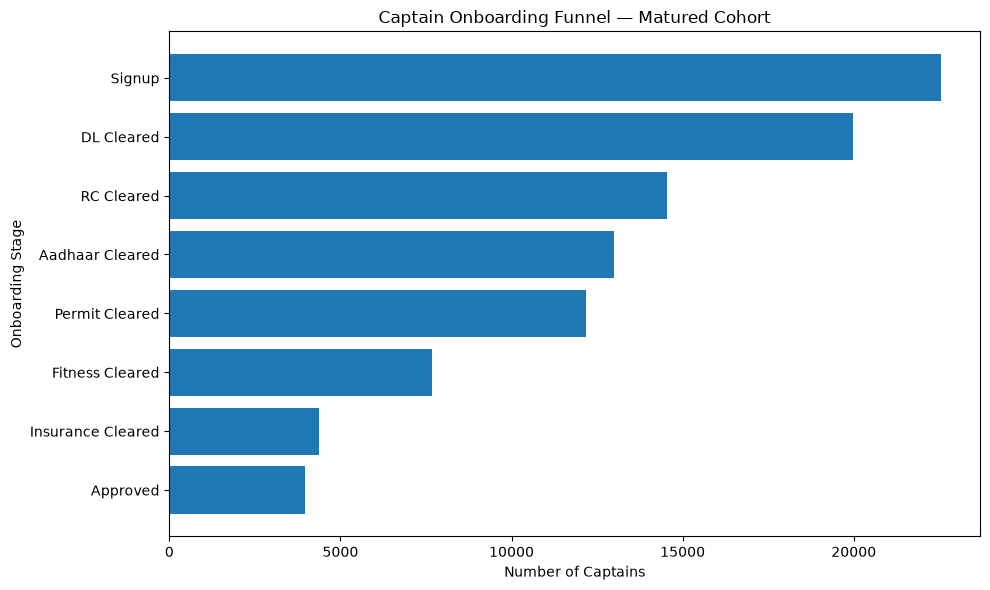

In [62]:
plt.figure(figsize=(10, 6))

plt.barh(
    funnel_table["stage"],
    funnel_table["captains"]
)

plt.xlabel("Number of Captains")
plt.ylabel("Onboarding Stage")
plt.title("Captain Onboarding Funnel — Matured Cohort")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    CHART_DIR / "a1_onboarding_funnel.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [63]:
print("Matured cohort:", len(funnel_base))

print(
    "Approved:",
    funnel_base["approved"].sum()
)

print(
    "Approval rate:",
    funnel_base["approved"].mean()
)

Matured cohort: 22561
Approved: 3969
Approval rate: 0.17592305305615885


In [64]:
funnel_table

,stage,captains,step_conversion_pct,cumulative_conversion_pct,drop_off
0,Signup,22561,100.00,100.00,0
1,DL Cleared,19967,88.50,88.50,2594
2,RC Cleared,14534,72.79,64.42,5433
3,Aadhaar Cleared,12988,89.36,57.57,1546
4,Permit Cleared,12170,93.70,53.94,818
5,Fitness Cleared,7689,63.18,34.08,4481
6,Insurance Cleared,4380,56.96,19.41,3309
7,Approved,3969,90.62,17.59,411


In [65]:
largest_leak

stage                        RC Cleared
captains                          14534
step_conversion_pct               72.79
cumulative_conversion_pct         64.42
drop_off                           5433
Name: 2, dtype: object

In [66]:
approved_check[stage_columns].mean()

DL_cleared           1.0
RC_cleared           1.0
AADHAAR_cleared      1.0
PERMIT_cleared       1.0
FITNESS_cleared      1.0
INSURANCE_cleared    1.0
dtype: float64

## 4. A2 — Diagnose the Biggest Fixable Leak

The funnel identifies RC, Fitness and Insurance as the largest stage-level losses.

We now segment these losses by failure reason, captain characteristics and time to distinguish large but potentially unavoidable losses from operationally addressable leakage.

In [67]:
# Define the captain groups lost at each major document stage

rc_drop = funnel_base[
    funnel_base["DL_cleared"]
    & ~funnel_base["RC_cleared"]
].copy()

fitness_drop = funnel_base[
    funnel_base["PERMIT_cleared"]
    & ~funnel_base["FITNESS_cleared"]
].copy()

insurance_drop = funnel_base[
    funnel_base["FITNESS_cleared"]
    & ~funnel_base["INSURANCE_cleared"]
].copy()

print("RC drop:", len(rc_drop))
print("Fitness drop:", len(fitness_drop))
print("Insurance drop:", len(insurance_drop))

RC drop: 5433
Fitness drop: 4481
Insurance drop: 3309


In [68]:
def failure_reason_analysis(drop_df, doc_type):
    """
    Summarise failure reasons for captains who dropped at a document stage.
    Uses the latest verification failure for that captain/document.
    """
    
    failures = doc_events[
        (doc_events["doc_type"] == doc_type)
        & (doc_events["event_type"] == "verification_fail")
        & (doc_events["captain_id"].isin(drop_df["captain_id"]))
    ].copy()
    
    latest_failure = (
        failures
        .sort_values("event_ts")
        .drop_duplicates(
            subset=["captain_id", "doc_type"],
            keep="last"
        )
    )
    
    result = (
        latest_failure["failure_reason"]
        .fillna("No recorded verification failure")
        .value_counts()
        .rename_axis("failure_reason")
        .reset_index(name="captains")
    )
    
    result["share_pct"] = (
        result["captains"] / len(drop_df) * 100
    ).round(2)
    
    return result


rc_failures = failure_reason_analysis(rc_drop, "RC")
fitness_failures = failure_reason_analysis(fitness_drop, "FITNESS")
insurance_failures = failure_reason_analysis(insurance_drop, "INSURANCE")

In [69]:
print("RC FAILURE REASONS")
display(rc_failures)

print("FITNESS FAILURE REASONS")
display(fitness_failures)

print("INSURANCE FAILURE REASONS")
display(insurance_failures)

RC FAILURE REASONS


,failure_reason,captains,share_pct
0,image_blurred,835,15.37
1,ocr_low_confidence,685,12.61
2,name_mismatch,402,7.40
3,document_expired,326,6.00
4,details_not_legible,316,5.82
5,wrong_document_type,292,5.37
6,duplicate_document,178,3.28


FITNESS FAILURE REASONS


,failure_reason,captains,share_pct
0,image_blurred,262,5.85
1,ocr_low_confidence,193,4.31
2,name_mismatch,121,2.70
3,document_expired,105,2.34
4,wrong_document_type,96,2.14
5,details_not_legible,84,1.87
6,duplicate_document,52,1.16


INSURANCE FAILURE REASONS


,failure_reason,captains,share_pct
0,image_blurred,213,6.44
1,ocr_low_confidence,143,4.32
2,name_mismatch,109,3.29
3,details_not_legible,98,2.96
4,document_expired,93,2.81
5,wrong_document_type,70,2.12
6,duplicate_document,39,1.18


In [70]:
def attempt_analysis(drop_df, doc_type):
    
    attempts = doc_events[
        (doc_events["doc_type"] == doc_type)
        & (doc_events["captain_id"].isin(drop_df["captain_id"]))
    ].copy()
    
    max_attempt = (
        attempts
        .groupby("captain_id")["attempt_no"]
        .max()
    )
    
    result = (
        max_attempt
        .value_counts()
        .sort_index()
        .rename_axis("max_attempt_no")
        .reset_index(name="captains")
    )
    
    result["share_pct"] = (
        result["captains"] / len(drop_df) * 100
    ).round(2)
    
    return result


rc_attempts = attempt_analysis(rc_drop, "RC")
fitness_attempts = attempt_analysis(fitness_drop, "FITNESS")
insurance_attempts = attempt_analysis(insurance_drop, "INSURANCE")

print("RC attempts")
display(rc_attempts)

print("Fitness attempts")
display(fitness_attempts)

print("Insurance attempts")
display(insurance_attempts)

RC attempts


,max_attempt_no,captains,share_pct
0,1,2280,41.97
1,2,599,11.03
2,3,155,2.85


Fitness attempts


,max_attempt_no,captains,share_pct
0,1,757,16.89
1,2,130,2.90
2,3,26,0.58


Insurance attempts


,max_attempt_no,captains,share_pct
0,1,610,18.43
1,2,115,3.48
2,3,40,1.21


In [71]:
def segment_dropoff(drop_df, column):
    
    result = (
        drop_df[column]
        .value_counts()
        .rename_axis(column)
        .reset_index(name="captains")
    )
    
    result["share_pct"] = (
        result["captains"] / len(drop_df) * 100
    ).round(2)
    
    return result


print("RC DROP — CITY")
display(segment_dropoff(rc_drop, "city"))

print("FITNESS DROP — CITY")
display(segment_dropoff(fitness_drop, "city"))

print("INSURANCE DROP — CITY")
display(segment_dropoff(insurance_drop, "city"))

RC DROP — CITY


,city,captains,share_pct
0,Hyderabad,1682,30.96
1,Delhi,1390,25.58
2,Bangalore,1196,22.01
3,Pune,1165,21.44


FITNESS DROP — CITY


,city,captains,share_pct
0,Delhi,1877,41.89
1,Hyderabad,1082,24.15
2,Bangalore,764,17.05
3,Pune,758,16.92


INSURANCE DROP — CITY


,city,captains,share_pct
0,Hyderabad,978,29.56
1,Delhi,958,28.95
2,Pune,687,20.76
3,Bangalore,686,20.73


In [72]:
def stage_drop_rate_by_segment(base_df, previous_stage, current_stage, segment):
    
    temp = base_df.copy()
    
    temp["eligible"] = temp[previous_stage]
    temp["dropped"] = (
        temp[previous_stage]
        & ~temp[current_stage]
    )
    
    result = (
        temp[temp["eligible"]]
        .groupby(segment)
        .agg(
            eligible=("eligible", "sum"),
            dropped=("dropped", "sum")
        )
        .reset_index()
    )
    
    result["drop_rate_pct"] = (
        result["dropped"] / result["eligible"] * 100
    ).round(2)
    
    return result.sort_values(
        "drop_rate_pct",
        ascending=False
    )

In [73]:
print("RC DROP RATE — CITY")

rc_city_rate = stage_drop_rate_by_segment(
    funnel_base,
    "DL_cleared",
    "RC_cleared",
    "city"
)

display(rc_city_rate)

RC DROP RATE — CITY


,city,eligible,dropped,drop_rate_pct
0,Bangalore,4333,1196,27.60
2,Hyderabad,6097,1682,27.59
1,Delhi,5169,1390,26.89
3,Pune,4368,1165,26.67


In [74]:
print("FITNESS DROP RATE — CITY")

fitness_city_rate = stage_drop_rate_by_segment(
    funnel_base,
    "PERMIT_cleared",
    "FITNESS_cleared",
    "city"
)

display(fitness_city_rate)

FITNESS DROP RATE — CITY


,city,eligible,dropped,drop_rate_pct
1,Delhi,4078,1877,46.03
3,Pune,2332,758,32.50
2,Hyderabad,3367,1082,32.14
0,Bangalore,2393,764,31.93


In [75]:
print("INSURANCE DROP RATE — CITY")

insurance_city_rate = stage_drop_rate_by_segment(
    funnel_base,
    "FITNESS_cleared",
    "INSURANCE_cleared",
    "city"
)

display(insurance_city_rate)

INSURANCE DROP RATE — CITY


,city,eligible,dropped,drop_rate_pct
3,Pune,1574,687,43.65
1,Delhi,2201,958,43.53
2,Hyderabad,2285,978,42.80
0,Bangalore,1629,686,42.11


In [76]:
print("RC — VEHICLE")

display(
    stage_drop_rate_by_segment(
        funnel_base,
        "DL_cleared",
        "RC_cleared",
        "vehicle_type"
    )
)

print("FITNESS — VEHICLE")

display(
    stage_drop_rate_by_segment(
        funnel_base,
        "PERMIT_cleared",
        "FITNESS_cleared",
        "vehicle_type"
    )
)

print("INSURANCE — VEHICLE")

display(
    stage_drop_rate_by_segment(
        funnel_base,
        "FITNESS_cleared",
        "INSURANCE_cleared",
        "vehicle_type"
    )
)

RC — VEHICLE


,vehicle_type,eligible,dropped,drop_rate_pct
1,Cab,7094,1962,27.66
0,Auto,9061,2453,27.07
2,ERickshaw,3812,1018,26.71


FITNESS — VEHICLE


,vehicle_type,eligible,dropped,drop_rate_pct
2,ERickshaw,4310,2428,56.33
0,Auto,4412,1177,26.68
1,Cab,3448,876,25.41


INSURANCE — VEHICLE


,vehicle_type,eligible,dropped,drop_rate_pct
1,Cab,2572,1135,44.13
0,Auto,3235,1408,43.52
2,ERickshaw,1882,766,40.70


In [77]:
print("RC — ACQUISITION CHANNEL")

display(
    stage_drop_rate_by_segment(
        funnel_base,
        "DL_cleared",
        "RC_cleared",
        "acquisition_channel"
    )
)

print("FITNESS — ACQUISITION CHANNEL")

display(
    stage_drop_rate_by_segment(
        funnel_base,
        "PERMIT_cleared",
        "FITNESS_cleared",
        "acquisition_channel"
    )
)

print("INSURANCE — ACQUISITION CHANNEL")

display(
    stage_drop_rate_by_segment(
        funnel_base,
        "FITNESS_cleared",
        "INSURANCE_cleared",
        "acquisition_channel"
    )
)

RC — ACQUISITION CHANNEL


,acquisition_channel,eligible,dropped,drop_rate_pct
3,paid_digital,2627,872,33.19
4,referral,4398,1262,28.69
1,gc_telecalling,1124,318,28.29
2,organic_app,6620,1860,28.10
0,fos_field,5198,1121,21.57


FITNESS — ACQUISITION CHANNEL


,acquisition_channel,eligible,dropped,drop_rate_pct
3,paid_digital,1414,687,48.59
1,gc_telecalling,681,273,40.09
2,organic_app,3881,1530,39.42
4,referral,2619,1017,38.83
0,fos_field,3575,974,27.24


INSURANCE — ACQUISITION CHANNEL


,acquisition_channel,eligible,dropped,drop_rate_pct
3,paid_digital,727,387,53.23
2,organic_app,2351,1075,45.73
4,referral,1602,714,44.57
1,gc_telecalling,408,172,42.16
0,fos_field,2601,961,36.95


In [78]:
print("RC — DEVICE")

display(
    stage_drop_rate_by_segment(
        funnel_base,
        "DL_cleared",
        "RC_cleared",
        "device_tier"
    )
)

print("FITNESS — DEVICE")

display(
    stage_drop_rate_by_segment(
        funnel_base,
        "PERMIT_cleared",
        "FITNESS_cleared",
        "device_tier"
    )
)

print("INSURANCE — DEVICE")

display(
    stage_drop_rate_by_segment(
        funnel_base,
        "FITNESS_cleared",
        "INSURANCE_cleared",
        "device_tier"
    )
)

RC — DEVICE


,device_tier,eligible,dropped,drop_rate_pct
1,low,9193,3008,32.72
2,mid,7678,1795,23.38
0,high,3096,630,20.35


FITNESS — DEVICE


,device_tier,eligible,dropped,drop_rate_pct
1,low,5396,2322,43.03
2,mid,4772,1574,32.98
0,high,2002,585,29.22


INSURANCE — DEVICE


,device_tier,eligible,dropped,drop_rate_pct
1,low,3074,1475,47.98
2,mid,3198,1314,41.09
0,high,1417,520,36.70


In [79]:
funnel_base["signup_month"] = (
    funnel_base["signup_ts"]
    .dt.to_period("M")
    .astype(str)
)

In [80]:
monthly_leaks = (
    funnel_base
    .groupby("signup_month")
    .agg(
        signups=("captain_id", "count"),
        rc_drop=("RC_cleared", lambda x: 0)
    )
    .reset_index()
)

In [81]:
monthly_volume = (
    funnel_base
    .groupby("signup_month")
    .agg(
        signups=("captain_id", "count"),
        rc_eligible=("DL_cleared", "sum"),
        rc_cleared=("RC_cleared", "sum"),
        fitness_eligible=("PERMIT_cleared", "sum"),
        fitness_cleared=("FITNESS_cleared", "sum"),
        insurance_eligible=("FITNESS_cleared", "sum"),
        insurance_cleared=("INSURANCE_cleared", "sum"),
        approved=("approved", "sum")
    )
    .reset_index()
)

monthly_volume["rc_drop"] = (
    monthly_volume["rc_eligible"]
    - monthly_volume["rc_cleared"]
)

monthly_volume["fitness_drop"] = (
    monthly_volume["fitness_eligible"]
    - monthly_volume["fitness_cleared"]
)

monthly_volume["insurance_drop"] = (
    monthly_volume["insurance_eligible"]
    - monthly_volume["insurance_cleared"]
)

monthly_volume

,signup_month,signups,rc_eligible,rc_cleared,fitness_eligible,fitness_cleared,insurance_eligible,insurance_cleared,approved,rc_drop,fitness_drop,insurance_drop
0,2026-01,3716,3290,2331,1972,1226,1226,699,631,959,746,527
1,2026-02,3600,3182,2314,2002,1273,1273,713,659,868,729,560
2,2026-03,4188,3719,2737,2297,1477,1477,842,751,982,820,635
3,2026-04,4123,3655,2685,2218,1394,1394,786,717,970,824,608
4,2026-05,4580,4049,2941,2424,1497,1497,848,774,1108,927,649
5,2026-06,2354,2072,1526,1257,822,822,492,437,546,435,330


In [82]:
def dropoff_event_diagnosis(drop_df, doc_type):
    
    events = doc_events[
        (doc_events["doc_type"] == doc_type)
        & (doc_events["captain_id"].isin(drop_df["captain_id"]))
    ].copy()
    
    summary = (
        events
        .groupby("captain_id")
        .agg(
            total_events=("event_id", "count"),
            uploads=("event_type", lambda x: (x == "upload_success").sum()),
            verification_passes=("event_type", lambda x: (x == "verification_pass").sum()),
            verification_fails=("event_type", lambda x: (x == "verification_fail").sum()),
            max_attempt=("attempt_no", "max")
        )
        .reset_index()
    )
    
    result = drop_df[["captain_id"]].merge(
        summary,
        on="captain_id",
        how="left"
    )
    
    for col in [
        "total_events",
        "uploads",
        "verification_passes",
        "verification_fails",
        "max_attempt"
    ]:
        result[col] = result[col].fillna(0)
    
    result["event_pattern"] = np.select(
        [
            result["verification_fails"] > 0,
            result["uploads"] > 0,
            result["total_events"] == 0
        ],
        [
            "verification_failed",
            "uploaded_no_verification_fail",
            "no_document_event"
        ],
        default="other"
    )
    
    return result

In [83]:
rc_diagnosis = dropoff_event_diagnosis(rc_drop, "RC")
fitness_diagnosis = dropoff_event_diagnosis(fitness_drop, "FITNESS")
insurance_diagnosis = dropoff_event_diagnosis(insurance_drop, "INSURANCE")

print("RC")
display(
    rc_diagnosis["event_pattern"]
    .value_counts()
    .rename_axis("event_pattern")
    .reset_index(name="captains")
)

print("FITNESS")
display(
    fitness_diagnosis["event_pattern"]
    .value_counts()
    .rename_axis("event_pattern")
    .reset_index(name="captains")
)

print("INSURANCE")
display(
    insurance_diagnosis["event_pattern"]
    .value_counts()
    .rename_axis("event_pattern")
    .reset_index(name="captains")
)

RC


,event_pattern,captains
0,verification_failed,3034
1,no_document_event,2399


FITNESS


,event_pattern,captains
0,no_document_event,3568
1,verification_failed,913


INSURANCE


,event_pattern,captains
0,no_document_event,2544
1,verification_failed,765


In [84]:
def complete_failure_analysis(drop_df, doc_type):
    
    diagnosis = dropoff_event_diagnosis(drop_df, doc_type)
    
    failures = doc_events[
        (doc_events["doc_type"] == doc_type)
        & (doc_events["event_type"] == "verification_fail")
        & (doc_events["captain_id"].isin(drop_df["captain_id"]))
    ].copy()
    
    latest_failure = (
        failures
        .sort_values("event_ts")
        .drop_duplicates(
            subset=["captain_id"],
            keep="last"
        )
    )
    
    result = diagnosis.merge(
        latest_failure[
            ["captain_id", "failure_reason"]
        ],
        on="captain_id",
        how="left"
    )
    
    result["failure_reason"] = (
        result["failure_reason"]
        .fillna("No verification failure recorded")
    )
    
    summary = (
        result["failure_reason"]
        .value_counts()
        .rename_axis("failure_reason")
        .reset_index(name="captains")
    )
    
    summary["share_of_stage_drop_pct"] = (
        summary["captains"] / len(drop_df) * 100
    ).round(2)
    
    return summary

In [85]:
rc_complete = complete_failure_analysis(rc_drop, "RC")
fitness_complete = complete_failure_analysis(fitness_drop, "FITNESS")
insurance_complete = complete_failure_analysis(insurance_drop, "INSURANCE")

print("RC — COMPLETE DIAGNOSIS")
display(rc_complete)

print("FITNESS — COMPLETE DIAGNOSIS")
display(fitness_complete)

print("INSURANCE — COMPLETE DIAGNOSIS")
display(insurance_complete)

RC — COMPLETE DIAGNOSIS


,failure_reason,captains,share_of_stage_drop_pct
0,No verification failure recorded,2399,44.16
1,image_blurred,835,15.37
2,ocr_low_confidence,685,12.61
3,name_mismatch,402,7.40
4,document_expired,326,6.00
5,details_not_legible,316,5.82
6,wrong_document_type,292,5.37
7,duplicate_document,178,3.28


FITNESS — COMPLETE DIAGNOSIS


,failure_reason,captains,share_of_stage_drop_pct
0,No verification failure recorded,3568,79.63
1,image_blurred,262,5.85
2,ocr_low_confidence,193,4.31
3,name_mismatch,121,2.70
4,document_expired,105,2.34
5,wrong_document_type,96,2.14
6,details_not_legible,84,1.87
7,duplicate_document,52,1.16


INSURANCE — COMPLETE DIAGNOSIS


,failure_reason,captains,share_of_stage_drop_pct
0,No verification failure recorded,2544,76.88
1,image_blurred,213,6.44
2,ocr_low_confidence,143,4.32
3,name_mismatch,109,3.29
4,details_not_legible,98,2.96
5,document_expired,93,2.81
6,wrong_document_type,70,2.12
7,duplicate_document,39,1.18


In [86]:
addressable_reasons = {
    "image_blurred",
    "ocr_low_confidence",
    "details_not_legible",
    "wrong_document_type"
}

def add_addressability(summary):
    summary = summary.copy()
    
    summary["potentially_addressable"] = (
        summary["failure_reason"]
        .isin(addressable_reasons)
    )
    
    return summary

rc_complete = add_addressability(rc_complete)
fitness_complete = add_addressability(fitness_complete)
insurance_complete = add_addressability(insurance_complete)

display(rc_complete)

,failure_reason,captains,share_of_stage_drop_pct,potentially_addressable
0,No verification failure recorded,2399,44.16,False
1,image_blurred,835,15.37,True
2,ocr_low_confidence,685,12.61,True
3,name_mismatch,402,7.40,False
4,document_expired,326,6.00,False
5,details_not_legible,316,5.82,True
6,wrong_document_type,292,5.37,True
7,duplicate_document,178,3.28,False


In [87]:
for name, df in [
    ("RC", rc_complete),
    ("Fitness", fitness_complete),
    ("Insurance", insurance_complete)
]:
    
    potentially_addressable = df.loc[
        df["potentially_addressable"],
        "captains"
    ].sum()
    
    print(
        f"{name}: {potentially_addressable} "
        f"potentially addressable failure cases"
    )

RC: 2128 potentially addressable failure cases
Fitness: 635 potentially addressable failure cases
Insurance: 524 potentially addressable failure cases


In [88]:
erickshaw_fitness = funnel_base[
    funnel_base["vehicle_type"] == "ERickshaw"
].copy()

print("ERickshaw captains:", len(erickshaw_fitness))

print(
    "Fitness eligible:",
    erickshaw_fitness["PERMIT_cleared"].sum()
)

print(
    "Fitness cleared:",
    erickshaw_fitness["FITNESS_cleared"].sum()
)

print(
    "Fitness drop rate:",
    (
        1 -
        erickshaw_fitness["FITNESS_cleared"].sum()
        / erickshaw_fitness["PERMIT_cleared"].sum()
    )
)

ERickshaw captains: 4310
Fitness eligible: 4310
Fitness cleared: 1882
Fitness drop rate: 0.5633410672853829


In [89]:
erickshaw_drop = fitness_drop[
    fitness_drop["vehicle_type"] == "ERickshaw"
]

display(
    complete_failure_analysis(
        erickshaw_drop,
        "FITNESS"
    )
)

,failure_reason,captains,share_of_stage_drop_pct
0,No verification failure recorded,2207,90.90
1,image_blurred,52,2.14
2,ocr_low_confidence,41,1.69
3,name_mismatch,40,1.65
4,wrong_document_type,27,1.11
5,document_expired,26,1.07
6,details_not_legible,21,0.86
7,duplicate_document,14,0.58


In [90]:
fitness_reason_vehicle = (
    doc_events[
        (doc_events["doc_type"] == "FITNESS")
        & (doc_events["event_type"] == "verification_fail")
        & (
            doc_events["captain_id"].isin(
                fitness_drop["captain_id"]
            )
        )
    ]
    .merge(
        captains[
            ["captain_id", "vehicle_type"]
        ],
        on="captain_id",
        how="left"
    )
)

fitness_reason_vehicle_summary = (
    fitness_reason_vehicle
    .groupby(
        ["vehicle_type", "failure_reason"]
    )
    .size()
    .reset_index(name="failures")
    .sort_values(
        ["vehicle_type", "failures"],
        ascending=[True, False]
    )
)

fitness_reason_vehicle_summary

,vehicle_type,failure_reason,failures
3,Auto,image_blurred,145
5,Auto,ocr_low_confidence,102
4,Auto,name_mismatch,55
1,Auto,document_expired,54
0,Auto,details_not_legible,45
6,Auto,wrong_document_type,40
2,Auto,duplicate_document,25
10,Cab,image_blurred,107
12,Cab,ocr_low_confidence,83
11,Cab,name_mismatch,41


In [91]:
fitness_city_vehicle = (
    funnel_base
    .groupby(["city", "vehicle_type"])
    .agg(
        eligible=("PERMIT_cleared", "sum"),
        cleared=("FITNESS_cleared", "sum")
    )
    .reset_index()
)

fitness_city_vehicle["drop"] = (
    fitness_city_vehicle["eligible"]
    - fitness_city_vehicle["cleared"]
)

fitness_city_vehicle["drop_rate_pct"] = (
    fitness_city_vehicle["drop"]
    / fitness_city_vehicle["eligible"]
    * 100
).round(2)

fitness_city_vehicle.sort_values(
    "drop_rate_pct",
    ascending=False
)

,city,vehicle_type,eligible,cleared,drop,drop_rate_pct
2,Bangalore,ERickshaw,487,203,284,58.32
8,Hyderabad,ERickshaw,655,277,378,57.71
5,Delhi,ERickshaw,2686,1186,1500,55.85
11,Pune,ERickshaw,482,216,266,55.19
3,Delhi,Auto,888,630,258,29.05
9,Pune,Auto,1326,969,357,26.92
6,Hyderabad,Auto,1357,1004,353,26.01
7,Hyderabad,Cab,1355,1004,351,25.90
10,Pune,Cab,524,389,135,25.76
1,Bangalore,Cab,1065,794,271,25.45


In [92]:
device_summary = (
    funnel_base
    .groupby("device_tier")
    .agg(
        captains=("captain_id", "count"),
        dl=("DL_cleared", "sum"),
        rc=("RC_cleared", "sum"),
        aadhaar=("AADHAAR_cleared", "sum"),
        fitness=("FITNESS_cleared", "sum"),
        insurance=("INSURANCE_cleared", "sum"),
        approved=("approved", "sum")
    )
    .reset_index()
)

device_summary

,device_tier,captains,dl,rc,aadhaar,fitness,insurance,approved
0,high,3548,3096,2466,2189,1417,897,807
1,low,10386,9193,6185,5563,3074,1599,1454
2,mid,8627,7678,5883,5236,3198,1884,1708


In [93]:
device_summary["a2o_pct"] = (
    device_summary["approved"]
    / device_summary["captains"]
    * 100
).round(2)

device_summary

,device_tier,captains,dl,rc,aadhaar,fitness,insurance,approved,a2o_pct
0,high,3548,3096,2466,2189,1417,897,807,22.75
1,low,10386,9193,6185,5563,3074,1599,1454,14.00
2,mid,8627,7678,5883,5236,3198,1884,1708,19.80


In [94]:
channel_summary = (
    funnel_base
    .groupby("acquisition_channel")
    .agg(
        captains=("captain_id", "count"),
        dl=("DL_cleared", "sum"),
        rc=("RC_cleared", "sum"),
        aadhaar=("AADHAAR_cleared", "sum"),
        permit=("PERMIT_cleared", "sum"),
        fitness=("FITNESS_cleared", "sum"),
        insurance=("INSURANCE_cleared", "sum"),
        approved=("approved", "sum")
    )
    .reset_index()
)

channel_summary["a2o_pct"] = (
    channel_summary["approved"]
    / channel_summary["captains"]
    * 100
).round(2)

channel_summary

,acquisition_channel,captains,dl,rc,aadhaar,permit,fitness,insurance,approved,a2o_pct
0,fos_field,5572,5198,4077,3812,3575,2601,1640,1490,26.74
1,gc_telecalling,1302,1124,806,718,681,408,236,196,15.05
2,organic_app,7576,6620,4760,4215,3881,2351,1276,1157,15.27
3,paid_digital,3138,2627,1755,1481,1414,727,340,315,10.04
4,referral,4973,4398,3136,2762,2619,1602,888,811,16.31


In [95]:
channel_summary["approval_gap_vs_best_pp"] = (
    channel_summary["a2o_pct"].max()
    - channel_summary["a2o_pct"]
).round(2)

channel_summary.sort_values(
    "a2o_pct",
    ascending=False
)

,acquisition_channel,captains,dl,rc,aadhaar,permit,fitness,insurance,approved,a2o_pct,approval_gap_vs_best_pp
0,fos_field,5572,5198,4077,3812,3575,2601,1640,1490,26.74,0.00
4,referral,4973,4398,3136,2762,2619,1602,888,811,16.31,10.43
2,organic_app,7576,6620,4760,4215,3881,2351,1276,1157,15.27,11.47
1,gc_telecalling,1302,1124,806,718,681,408,236,196,15.05,11.69
3,paid_digital,3138,2627,1755,1481,1414,727,340,315,10.04,16.70


In [96]:
full_months = monthly_volume[
    monthly_volume["signup_month"].isin([
        "2026-01",
        "2026-02",
        "2026-03",
        "2026-04",
        "2026-05"
    ])
].copy()

monthly_avg = full_months[
    [
        "rc_drop",
        "fitness_drop",
        "insurance_drop",
        "approved"
    ]
].mean()

monthly_avg

rc_drop           977.4
fitness_drop      809.2
insurance_drop    595.8
approved          706.4
dtype: float64

In [97]:
scenario_recovery = pd.DataFrame({
    "recovery_rate": [0.10, 0.25, 0.50]
})

for leak in [
    "rc_drop",
    "fitness_drop",
    "insurance_drop"
]:
    
    scenario_recovery[
        f"{leak}_additional_approvals"
    ] = (
        monthly_avg[leak]
        * scenario_recovery["recovery_rate"]
    ).round(0)

scenario_recovery

,recovery_rate,rc_drop_additional_approvals,fitness_drop_additional_approvals,insurance_drop_additional_approvals
0,0.10,98.0,81.0,60.0
1,0.25,244.0,202.0,149.0
2,0.50,489.0,405.0,298.0


In [98]:
downstream_conversion = {
    "RC": (
        funnel_base.loc[
            funnel_base["RC_cleared"],
            "approved"
        ].mean()
    ),
    
    "Fitness": (
        funnel_base.loc[
            funnel_base["FITNESS_cleared"],
            "approved"
        ].mean()
    ),
    
    "Insurance": (
        funnel_base.loc[
            funnel_base["INSURANCE_cleared"],
            "approved"
        ].mean()
    )
}

pd.Series(downstream_conversion)

RC           0.273084
Fitness      0.516192
Insurance    0.906164
dtype: float64

## 5. A3 — Campaign Evaluation: CAMP_WA_002

The campaign should be evaluated based on incremental onboarding completion rather than raw conversion among recipients.

The primary question is whether exposure to CAMP_WA_002 is associated with a meaningful increase in A2O after accounting for observable differences in captain eligibility and pre-campaign onboarding status.

In [99]:
camp = nudges[
    nudges["campaign_id"] == "CAMP_WA_002"
].copy()

print("CAMP_WA_002 rows:", len(camp))
print("Unique captains:", camp["captain_id"].nunique())

display(camp.head())

CAMP_WA_002 rows: 8673
Unique captains: 8673


,captain_id,campaign_id,channel,sent_ts,delivered,clicked
1,CPT102049,CAMP_WA_002,whatsapp,2026-01-02 20:02:31.634258914,1,0
2,CPT123006,CAMP_WA_002,whatsapp,2026-01-03 11:32:05.154545929,1,1
3,CPT105916,CAMP_WA_002,whatsapp,2026-01-05 01:25:34.559467887,1,1
5,CPT110674,CAMP_WA_002,whatsapp,2026-01-03 21:38:25.376680106,0,1
7,CPT115782,CAMP_WA_002,whatsapp,2026-01-04 19:53:26.995722915,1,1


In [100]:
campaign_delivery = {
    "sent": len(camp),
    "unique_captains": camp["captain_id"].nunique(),
    "delivered": camp["delivered"].sum(),
    "clicked": camp["clicked"].sum()
}

campaign_delivery

{'sent': 8673,
 'unique_captains': 8673,
 'delivered': np.int64(8058),
 'clicked': np.int64(3569)}

In [101]:
print(
    "Delivery rate:",
    camp["delivered"].mean()
)

print(
    "Click rate:",
    camp["clicked"].mean()
)

print(
    "Click-through among delivered:",
    camp.loc[camp["delivered"] == 1, "clicked"].mean()
)

Delivery rate: 0.9290902801798686
Click rate: 0.4115069756716246
Click-through among delivered: 0.4117647058823529


In [102]:
campaign_frequency = (
    camp
    .groupby("captain_id")
    .size()
    .value_counts()
    .sort_index()
    .rename_axis("number_of_sends")
    .reset_index(name="captains")
)

campaign_frequency

,number_of_sends,captains
0,1,8673


In [103]:
campaign_analysis = camp.merge(
    captain_outcomes,
    on="captain_id",
    how="left"
)

print("Campaign rows after merge:", len(campaign_analysis))
print("Unique captains:", campaign_analysis["captain_id"].nunique())

Campaign rows after merge: 8673
Unique captains: 8673


In [104]:
display(
    campaign_analysis[
        [
            "captain_id",
            "sent_ts",
            "delivered",
            "clicked",
            "signup_ts",
            "decision_ts",
            "final_status",
            "days_to_decision"
        ]
    ].head(10)
)

,captain_id,sent_ts,delivered,clicked,signup_ts,decision_ts,final_status,days_to_decision
0,CPT102049,2026-01-02 20:02:31.634258914,1,0,2026-01-01 07:02:00,NaT,dropped_in_docs,NaN
1,CPT123006,2026-01-03 11:32:05.154545929,1,1,2026-01-01 07:15:00,NaT,dropped_in_docs,NaN
2,CPT105916,2026-01-05 01:25:34.559467887,1,1,2026-01-01 07:32:00,2026-01-07 09:40:02.632133424,approved,6.088919
3,CPT110674,2026-01-03 21:38:25.376680106,0,1,2026-01-01 08:39:00,NaT,dropped_in_docs,NaN
4,CPT115782,2026-01-04 19:53:26.995722915,1,1,2026-01-01 09:10:00,2026-01-07 21:52:09.682255462,approved,6.529279
5,CPT115990,2026-01-02 12:07:52.213424314,1,1,2026-01-01 09:18:00,NaT,dropped_in_docs,NaN
6,CPT117473,2026-01-04 03:09:32.880608364,0,1,2026-01-01 09:59:00,NaT,dropped_in_docs,NaN
7,CPT122490,2026-01-03 23:22:53.846254517,1,0,2026-01-01 10:04:00,NaT,dropped_in_docs,NaN
8,CPT108728,2026-01-04 23:27:50.698288152,1,0,2026-01-01 10:07:00,NaT,dropped_in_docs,NaN
9,CPT101207,2026-01-04 05:17:15.494863220,1,1,2026-01-01 11:31:00,2026-01-07 20:41:13.575135833,approved,6.382102


In [105]:
campaign_analysis["hours_from_signup"] = (
    campaign_analysis["sent_ts"]
    - campaign_analysis["signup_ts"]
).dt.total_seconds() / 3600

campaign_analysis["hours_from_signup"].describe(
    percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
)

count    8673.000000
mean       56.721898
std        20.757396
min         9.404725
1%         21.766569
10%        33.235479
25%        41.855489
50%        53.531545
75%        68.325829
90%        84.842734
99%       118.187784
max       184.939012
Name: hours_from_signup, dtype: float64

In [107]:
campaign_captains = set(
    camp["captain_id"].unique()
)

matured_ids = set(
    terminal_matured["captain_id"]
)

campaign_matured = terminal_matured[
    terminal_matured["captain_id"].isin(campaign_captains)
].copy()

non_campaign_matured = terminal_matured[
    ~terminal_matured["captain_id"].isin(campaign_captains)
].copy()

print("Campaign exposed:", len(campaign_matured))
print("Not exposed:", len(non_campaign_matured))

Campaign exposed: 7980
Not exposed: 14580


In [108]:
naive_campaign_comparison = pd.DataFrame({
    "group": [
        "CAMP_WA_002 exposed",
        "Not exposed"
    ],
    "captains": [
        len(campaign_matured),
        len(non_campaign_matured)
    ],
    "approved": [
        campaign_matured["final_status"].eq("approved").sum(),
        non_campaign_matured["final_status"].eq("approved").sum()
    ]
})

naive_campaign_comparison["a2o_pct"] = (
    naive_campaign_comparison["approved"]
    / naive_campaign_comparison["captains"]
    * 100
).round(2)

naive_campaign_comparison

,group,captains,approved,a2o_pct
0,CAMP_WA_002 exposed,7980,2329,29.19
1,Not exposed,14580,1640,11.25


In [109]:
# Merge document events with signup information
campaign_events = camp[
    ["captain_id", "sent_ts"]
].merge(
    captains[
        ["captain_id", "signup_ts"]
    ],
    on="captain_id",
    how="left"
)

# Keep document events that happened before the campaign message
pre_campaign_events = campaign_events.merge(
    doc_events,
    on="captain_id",
    how="left"
)

pre_campaign_events = pre_campaign_events[
    pre_campaign_events["event_ts"] < pre_campaign_events["sent_ts"]
].copy()

In [110]:
def stage_before_campaign(row):
    
    captain_id = row["captain_id"]
    sent_ts = row["sent_ts"]
    vehicle = row["vehicle_type"]
    
    events = doc_events[
        (doc_events["captain_id"] == captain_id)
        & (doc_events["event_type"] == "verification_pass")
        & (doc_events["event_ts"] < sent_ts)
    ].copy()
    
    passed_docs = set(events["doc_type"])
    
    if "DL" not in passed_docs:
        return "Signup"
    
    if "RC" not in passed_docs:
        return "DL"
    
    if "AADHAAR" not in passed_docs:
        return "RC"
    
    if vehicle in ["Auto", "Cab"]:
        if "PERMIT" not in passed_docs:
            return "AADHAAR"
    
    if "FITNESS" not in passed_docs:
        return "Permit/Aadhaar"
    
    if "INSURANCE" not in passed_docs:
        return "Fitness"
    
    return "Insurance"

In [111]:
campaign_analysis[
    campaign_analysis["hours_from_signup"] < 0
].shape

(0, 20)

In [113]:
# Start with campaign recipients
campaign_stage = campaign_analysis[
    [
        "captain_id",
        "sent_ts",
        "signup_ts",
        "city",
        "vehicle_type",
        "acquisition_channel",
        "device_tier",
        "app_language",
        "age_band",
        "final_status"
    ]
].copy()

# Add document pass timestamps
campaign_stage = campaign_stage.merge(
    doc_pass_times,
    on="captain_id",
    how="left"
)

# Ensure expected document columns exist
for col in ["DL", "RC", "AADHAAR", "PERMIT", "FITNESS", "INSURANCE"]:
    if col not in campaign_stage.columns:
        campaign_stage[col] = pd.NaT

# Determine how many required documents had passed
# BEFORE the campaign was sent.

campaign_stage["DL_before"] = (
    campaign_stage["DL"].notna()
    & (campaign_stage["DL"] <= campaign_stage["sent_ts"])
)

campaign_stage["RC_before"] = (
    campaign_stage["DL_before"]
    & campaign_stage["RC"].notna()
    & (campaign_stage["RC"] <= campaign_stage["sent_ts"])
)

campaign_stage["AADHAAR_before"] = (
    campaign_stage["RC_before"]
    & campaign_stage["AADHAAR"].notna()
    & (campaign_stage["AADHAAR"] <= campaign_stage["sent_ts"])
)

campaign_stage["PERMIT_before"] = (
    campaign_stage["AADHAAR_before"]
    & campaign_stage["PERMIT"].notna()
    & (campaign_stage["PERMIT"] <= campaign_stage["sent_ts"])
)

campaign_stage["FITNESS_before"] = (
    campaign_stage["PERMIT_before"]
    & campaign_stage["FITNESS"].notna()
    & (campaign_stage["FITNESS"] <= campaign_stage["sent_ts"])
)

campaign_stage["INSURANCE_before"] = (
    campaign_stage["FITNESS_before"]
    & campaign_stage["INSURANCE"].notna()
    & (campaign_stage["INSURANCE"] <= campaign_stage["sent_ts"])
)

In [114]:
def get_pre_campaign_stage(row):
    
    if not row["DL_before"]:
        return "Signup"
    
    if not row["RC_before"]:
        return "DL"
    
    if not row["AADHAAR_before"]:
        return "RC"
    
    if row["vehicle_type"] in ["Auto", "Cab"]:
        if not row["PERMIT_before"]:
            return "Aadhaar"
    
    if not row["FITNESS_before"]:
        return "Permit/Aadhaar"
    
    if not row["INSURANCE_before"]:
        return "Fitness"
    
    return "Insurance"


campaign_stage["pre_campaign_stage"] = campaign_stage.apply(
    get_pre_campaign_stage,
    axis=1
)

campaign_stage["pre_campaign_stage"].value_counts()

pre_campaign_stage
RC                7734
Aadhaar            677
Permit/Aadhaar     260
Fitness              2
Name: count, dtype: int64

In [115]:
campaign_stage_summary = (
    campaign_stage
    .groupby("pre_campaign_stage")
    .size()
    .reset_index(name="captains")
)

campaign_stage_summary["share_pct"] = (
    campaign_stage_summary["captains"]
    / len(campaign_stage)
    * 100
).round(2)

campaign_stage_summary

,pre_campaign_stage,captains,share_pct
0,Aadhaar,677,7.81
1,Fitness,2,0.02
2,Permit/Aadhaar,260,3.00
3,RC,7734,89.17


In [116]:
analysis_df = terminal_matured.copy()

analysis_df["wa_002"] = (
    analysis_df["captain_id"].isin(
        set(camp["captain_id"])
    ).astype(int)
)

analysis_df["approved_binary"] = (
    analysis_df["final_status"] == "approved"
).astype(int)

analysis_df["signup_date"] = (
    analysis_df["signup_ts"].dt.date
)

analysis_df["signup_week"] = (
    analysis_df["signup_ts"]
    .dt.to_period("W")
    .astype(str)
)

analysis_df["signup_hour"] = (
    analysis_df["signup_ts"].dt.hour
)

In [117]:
campaign_timing = camp[
    ["captain_id", "sent_ts"]
].copy()

campaign_timing["hours_from_signup"] = (
    campaign_timing["sent_ts"]
    - captains.set_index("captain_id")
      .loc[
          campaign_timing["captain_id"],
          "signup_ts"
      ]
      .values
).dt.total_seconds() / 3600

In [118]:
campaign_timing = camp[
    ["captain_id", "sent_ts"]
].merge(
    captains[
        ["captain_id", "signup_ts"]
    ],
    on="captain_id",
    how="left"
)

campaign_timing["hours_from_signup"] = (
    campaign_timing["sent_ts"]
    - campaign_timing["signup_ts"]
).dt.total_seconds() / 3600

In [119]:
analysis_df = analysis_df.merge(
    campaign_timing[
        ["captain_id", "sent_ts", "hours_from_signup"]
    ],
    on="captain_id",
    how="left"
)

In [120]:
import statsmodels.formula.api as smf

model_df = analysis_df.copy()

formula = """
approved_binary ~ wa_002
+ C(city)
+ C(vehicle_type)
+ C(acquisition_channel)
+ C(device_tier)
+ C(app_language)
+ C(age_band)
+ C(signup_week)
"""

model = smf.logit(
    formula=formula,
    data=model_df
).fit(
    disp=False
)

print(model.summary())

                           Logit Regression Results                           
Dep. Variable:        approved_binary   No. Observations:                22560
Model:                          Logit   Df Residuals:                    22516
Method:                           MLE   Df Model:                           43
Date:                Wed, 09 Sep 2026   Pseudo R-squ.:                 0.08702
Time:                        13:15:11   Log-Likelihood:                -9580.9
converged:                       True   LL-Null:                       -10494.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                   -1.2263      0.160     -7.672      0.000      -1.540      -0.913
C(city)[T.Delhi]                         

In [121]:
wa_coef = model.params["wa_002"]
wa_se = model.bse["wa_002"]
wa_pvalue = model.pvalues["wa_002"]

print("WA coefficient:", wa_coef)
print("Standard error:", wa_se)
print("p-value:", wa_pvalue)

WA coefficient: 1.1536202860209277
Standard error: 0.03672820339568751
p-value: 1.4935754762245006e-216


In [122]:
pred_treated = model_df.copy()
pred_control = model_df.copy()

pred_treated["wa_002"] = 1
pred_control["wa_002"] = 0

p_treated = model.predict(pred_treated)
p_control = model.predict(pred_control)

adjusted_effect = (
    p_treated.mean()
    - p_control.mean()
)

adjusted_treated = p_treated.mean()
adjusted_control = p_control.mean()

print(f"Adjusted A2O with WA: {adjusted_treated:.2%}")
print(f"Adjusted A2O without WA: {adjusted_control:.2%}")
print(f"Adjusted effect: {adjusted_effect:.2%}")

Adjusted A2O with WA: 28.29%
Adjusted A2O without WA: 11.50%
Adjusted effect: 16.79%


In [123]:
rng = np.random.default_rng(42)

bootstrap_effects = []

for i in range(300):
    
    sample_idx = rng.choice(
        len(model_df),
        size=len(model_df),
        replace=True
    )
    
    sample = model_df.iloc[sample_idx].copy()
    
    try:
        boot_model = smf.logit(
            formula,
            data=sample
        ).fit(
            disp=False,
            maxiter=200
        )
        
        treated = sample.copy()
        control = sample.copy()
        
        treated["wa_002"] = 1
        control["wa_002"] = 0
        
        effect = (
            boot_model.predict(treated).mean()
            - boot_model.predict(control).mean()
        )
        
        bootstrap_effects.append(effect)
        
    except Exception:
        continue

bootstrap_effects = np.array(bootstrap_effects)

ci_low = np.percentile(
    bootstrap_effects,
    2.5
)

ci_high = np.percentile(
    bootstrap_effects,
    97.5
)

print("Bootstrap iterations:", len(bootstrap_effects))
print(f"Adjusted effect: {adjusted_effect:.2%}")
print(f"95% CI: [{ci_low:.2%}, {ci_high:.2%}]")

Bootstrap iterations: 300
Adjusted effect: 16.79%
95% CI: [15.76%, 17.98%]


In [124]:
exposed_terminal = analysis_df[
    analysis_df["wa_002"] == 1
]

exposed_terminal["approved_binary"].mean()

np.float64(0.2918546365914787)

In [125]:
observed_exposed = exposed_terminal["approved_binary"].sum()

counterfactual_exposed = (
    p_control[
        analysis_df["wa_002"].values == 1
    ].sum()
)

incremental_approvals = (
    observed_exposed
    - counterfactual_exposed
)

print("Observed approvals among exposed:", observed_exposed)
print(
    "Estimated counterfactual approvals:",
    round(counterfactual_exposed, 1)
)
print(
    "Estimated incremental approvals:",
    round(incremental_approvals, 1)
)

Observed approvals among exposed: 2329
Estimated counterfactual approvals: 953.8
Estimated incremental approvals: 1375.2


In [126]:
current_exposure = analysis_df["wa_002"].sum()

print("Current WA exposure:", current_exposure)
print("5x exposure:", current_exposure * 5)

Current WA exposure: 7980
5x exposure: 39900


In [127]:
incremental_per_exposed = (
    incremental_approvals / current_exposure
)

print(
    "Estimated incremental approvals per exposed captain:",
    incremental_per_exposed
)

Estimated incremental approvals per exposed captain: 0.17233032712060936


In [128]:
five_x_incremental = (
    incremental_per_exposed
    * current_exposure
    * 5
)

print(
    "Illustrative 5x incremental approvals:",
    round(five_x_incremental)
)

Illustrative 5x incremental approvals: 6876


In [129]:
segment_results = []

for col in [
    "city",
    "vehicle_type",
    "acquisition_channel",
    "device_tier"
]:
    
    for segment in model_df[col].dropna().unique():
        
        temp = model_df[
            model_df[col] == segment
        ].copy()
        
        exposed = temp[
            temp["wa_002"] == 1
        ]
        
        control = temp[
            temp["wa_002"] == 0
        ]
        
        if len(exposed) >= 30 and len(control) >= 30:
            
            segment_results.append({
                "segment_type": col,
                "segment": segment,
                "exposed_n": len(exposed),
                "control_n": len(control),
                "exposed_a2o": exposed["approved_binary"].mean(),
                "control_a2o": control["approved_binary"].mean(),
                "raw_difference_pp": (
                    exposed["approved_binary"].mean()
                    - control["approved_binary"].mean()
                ) * 100
            })

segment_results = pd.DataFrame(segment_results)

segment_results.sort_values(
    "raw_difference_pp",
    ascending=False
)

,segment_type,segment,exposed_n,control_n,exposed_a2o,control_a2o,raw_difference_pp
6,vehicle_type,ERickshaw,1526,2784,0.380734,0.156250,22.448394
10,acquisition_channel,fos_field,2252,3320,0.389432,0.184639,20.479306
14,device_tier,high,1318,2230,0.349772,0.155157,19.461543
1,city,Hyderabad,2430,4490,0.290947,0.105791,18.515586
3,city,Delhi,2051,3787,0.313506,0.128598,18.490777
13,device_tier,mid,3242,5385,0.313387,0.128505,18.488169
5,vehicle_type,Cab,2830,5197,0.282332,0.097749,18.458345
8,acquisition_channel,referral,1724,3248,0.281323,0.100369,18.095305
2,city,Bangalore,1713,3212,0.291302,0.110523,18.077877
9,acquisition_channel,gc_telecalling,458,844,0.259825,0.091232,16.859310


In [130]:
balance_cols = [
    "city",
    "vehicle_type",
    "acquisition_channel",
    "device_tier",
    "app_language",
    "age_band"
]

balance_results = []

for col in balance_cols:
    
    temp = (
        analysis_df
        .groupby(["wa_002", col])
        .size()
        .reset_index(name="captains")
    )
    
    temp["share_pct"] = (
        temp["captains"]
        /
        temp.groupby("wa_002")["captains"]
        .transform("sum")
        * 100
    ).round(2)
    
    temp["group"] = temp["wa_002"].map({
        0: "Not exposed",
        1: "WA exposed"
    })
    
    balance_results.append(
        temp[
            ["group", col, "captains", "share_pct"]
        ]
    )

balance_table = pd.concat(
    balance_results,
    ignore_index=True
)

display(balance_table)

,group,city,captains,share_pct,vehicle_type,acquisition_channel,device_tier,app_language,age_band
0,Not exposed,Bangalore,3212,22.03,NaN,NaN,NaN,NaN,NaN
1,Not exposed,Delhi,3787,25.97,NaN,NaN,NaN,NaN,NaN
2,Not exposed,Hyderabad,4490,30.80,NaN,NaN,NaN,NaN,NaN
3,Not exposed,Pune,3091,21.20,NaN,NaN,NaN,NaN,NaN
4,WA exposed,Bangalore,1713,21.47,NaN,NaN,NaN,NaN,NaN
5,WA exposed,Delhi,2051,25.70,NaN,NaN,NaN,NaN,NaN
6,WA exposed,Hyderabad,2430,30.45,NaN,NaN,NaN,NaN,NaN
7,WA exposed,Pune,1786,22.38,NaN,NaN,NaN,NaN,NaN
8,Not exposed,NaN,6599,45.26,Auto,NaN,NaN,NaN,NaN
9,Not exposed,NaN,5197,35.64,Cab,NaN,NaN,NaN,NaN


In [131]:
for col in balance_cols:
    
    print("\n" + "=" * 60)
    print(col.upper())
    
    comparison = pd.crosstab(
        analysis_df[col],
        analysis_df["wa_002"],
        normalize="columns"
    ) * 100
    
    comparison.columns = [
        "Not_exposed_pct",
        "WA_exposed_pct"
    ]
    
    comparison["difference_pp"] = (
        comparison["WA_exposed_pct"]
        -
        comparison["Not_exposed_pct"]
    )
    
    display(
        comparison.round(2)
    )


CITY


,Not_exposed_pct,WA_exposed_pct,difference_pp
city,,,
Bangalore,22.03,21.47,-0.56
Delhi,25.97,25.70,-0.27
Hyderabad,30.80,30.45,-0.34
Pune,21.20,22.38,1.18



VEHICLE_TYPE


,Not_exposed_pct,WA_exposed_pct,difference_pp
vehicle_type,,,
Auto,45.26,45.41,0.15
Cab,35.64,35.46,-0.18
ERickshaw,19.09,19.12,0.03



ACQUISITION_CHANNEL


...

,Not_exposed_pct,WA_exposed_pct,difference_pp
device_tier,,,
high,15.29,16.52,1.22
low,47.77,42.86,-4.91
mid,36.93,40.63,3.69



APP_LANGUAGE


,Not_exposed_pct,WA_exposed_pct,difference_pp
app_language,,,
en,19.86,19.54,-0.32
hi,20.04,19.27,-0.77
kn,20.08,20.45,0.38
mr,19.90,19.92,0.03
te,20.13,20.81,0.68



AGE_BAND


,Not_exposed_pct,WA_exposed_pct,difference_pp
age_band,,,
18-24,18.18,17.91,-0.28
25-34,41.51,41.67,0.16
35-44,28.05,29.02,0.98
45+,12.26,11.40,-0.86


In [132]:
timing_comparison = (
    analysis_df
    .groupby("wa_002")
    .agg(
        captains=("captain_id", "count"),
        median_signup=("signup_ts", "median"),
        min_signup=("signup_ts", "min"),
        max_signup=("signup_ts", "max")
    )
)

timing_comparison

,captains,median_signup,min_signup,max_signup
wa_002,,,,
0,14580,2026-03-30 09:08:00,2026-01-01 06:08:00,2026-06-15 21:24:00
1,7980,2026-03-30 10:50:00,2026-01-01 07:02:00,2026-06-15 21:56:00


In [134]:
channel_balance = pd.crosstab(
    analysis_df["acquisition_channel"],
    analysis_df["wa_002"],
    normalize="columns"
) * 100

channel_balance.columns = [
    "Not_exposed_pct",
    "WA_exposed_pct"
]

channel_balance["difference_pp"] = (
    channel_balance["WA_exposed_pct"]
    - channel_balance["Not_exposed_pct"]
)

channel_balance.round(2)

,Not_exposed_pct,WA_exposed_pct,difference_pp
acquisition_channel,,,
fos_field,22.77,28.22,5.45
gc_telecalling,5.79,5.74,-0.05
organic_app,34.38,32.12,-2.26
paid_digital,14.78,12.32,-2.46
referral,22.28,21.60,-0.67


In [135]:
vehicle_balance = pd.crosstab(
    analysis_df["vehicle_type"],
    analysis_df["wa_002"],
    normalize="columns"
) * 100

vehicle_balance.columns = [
    "Not_exposed_pct",
    "WA_exposed_pct"
]

vehicle_balance["difference_pp"] = (
    vehicle_balance["WA_exposed_pct"]
    - vehicle_balance["Not_exposed_pct"]
)

vehicle_balance.round(2)

,Not_exposed_pct,WA_exposed_pct,difference_pp
vehicle_type,,,
Auto,45.26,45.41,0.15
Cab,35.64,35.46,-0.18
ERickshaw,19.09,19.12,0.03


In [136]:
device_balance = pd.crosstab(
    analysis_df["device_tier"],
    analysis_df["wa_002"],
    normalize="columns"
) * 100

device_balance.columns = [
    "Not_exposed_pct",
    "WA_exposed_pct"
]

device_balance["difference_pp"] = (
    device_balance["WA_exposed_pct"]
    - device_balance["Not_exposed_pct"]
)

device_balance.round(2)

,Not_exposed_pct,WA_exposed_pct,difference_pp
device_tier,,,
high,15.29,16.52,1.22
low,47.77,42.86,-4.91
mid,36.93,40.63,3.69


In [137]:
exposed_stage_outcome = (
    campaign_stage
    .groupby("pre_campaign_stage")
    .agg(
        captains=("captain_id", "count")
    )
    .reset_index()
)

exposed_stage_outcome

,pre_campaign_stage,captains
0,Aadhaar,677
1,Fitness,2
2,Permit/Aadhaar,260
3,RC,7734


In [138]:
exposed_stage_outcome = (
    campaign_stage
    .merge(
        analysis_df[
            ["captain_id", "approved_binary"]
        ],
        on="captain_id",
        how="left"
    )
    .groupby("pre_campaign_stage")
    .agg(
        captains=("captain_id", "count"),
        approved=("approved_binary", "sum")
    )
    .reset_index()
)

exposed_stage_outcome["a2o_pct"] = (
    exposed_stage_outcome["approved"]
    / exposed_stage_outcome["captains"]
    * 100
).round(2)

exposed_stage_outcome

,pre_campaign_stage,captains,approved,a2o_pct
0,Aadhaar,677,167.0,24.67
1,Fitness,2,2.0,100.00
2,Permit/Aadhaar,260,96.0,36.92
3,RC,7734,2064.0,26.69


In [139]:
rc_population = funnel_base[
    funnel_base["RC_cleared"] == True
].copy()

print("RC-cleared population:", len(rc_population))

RC-cleared population: 14534


In [140]:
rc_population["wa_002"] = (
    rc_population["captain_id"]
    .isin(set(camp["captain_id"]))
    .astype(int)
)

rc_population["approved_binary"] = (
    rc_population["approved"]
).astype(int)

print(
    rc_population["wa_002"].value_counts()
)

wa_002
1    7981
0    6553
Name: count, dtype: int64


In [141]:
rc_campaign_comparison = (
    rc_population
    .groupby("wa_002")
    .agg(
        captains=("captain_id", "count"),
        approved=("approved_binary", "sum")
    )
    .reset_index()
)

rc_campaign_comparison["a2o_pct"] = (
    rc_campaign_comparison["approved"]
    /
    rc_campaign_comparison["captains"]
    * 100
).round(2)

rc_campaign_comparison

,wa_002,captains,approved,a2o_pct
0,0,6553,1640,25.03
1,1,7981,2329,29.18


In [142]:
rc_campaign_comparison["group"] = (
    rc_campaign_comparison["wa_002"]
    .map({
        0: "No WA",
        1: "WA"
    })
)

display(
    rc_campaign_comparison[
        ["group", "captains", "approved", "a2o_pct"]
    ]
)

,group,captains,approved,a2o_pct
0,No WA,6553,1640,25.03
1,WA,7981,2329,29.18


In [ ]:

wa_002_captains = set(
    nudges.loc[
        nudges["campaign_id"] == "CAMP_WA_002",
        "captain_id"
    ]
)

# Add treatment/exposure flag to RC population
rc_population["wa_002"] = (
    rc_population["captain_id"].isin(wa_002_captains)
)

print("RC population:", len(rc_population))
print("WA-002 exposed:", rc_population["wa_002"].sum())
print("Not exposed:", (~rc_population["wa_002"]).sum())

RC population: 14534
WA-002 exposed: 7981
Not exposed: 6553


In [ ]:


rc_channel = (
    rc_population
    .groupby(
        ["acquisition_channel", "wa_002"]
    )
    .agg(
        captains=("captain_id", "count"),
        approved=("approved", "sum")
    )
    .reset_index()
)

rc_channel["a2o_pct"] = (
    rc_channel["approved"]
    / rc_channel["captains"]
    * 100
).round(2)

display(
    rc_channel.sort_values(
        ["acquisition_channel", "wa_002"]
    )
)

,acquisition_channel,wa_002,captains,approved,a2o_pct
0,fos_field,False,1825,613,33.59
1,fos_field,True,2252,877,38.94
2,gc_telecalling,False,348,77,22.13
3,gc_telecalling,True,458,119,25.98
4,organic_app,False,2197,487,22.17
5,organic_app,True,2563,670,26.14
6,paid_digital,False,772,137,17.75
7,paid_digital,True,983,178,18.11
8,referral,False,1411,326,23.10
9,referral,True,1725,485,28.12


In [ ]:

rc_channel = (
    rc_population
    .groupby(["acquisition_channel", "wa_002"])
    .agg(
        captains=("captain_id", "count"),
        approved=("approved", "sum")
    )
    .reset_index()
)

rc_channel["a2o_pct"] = (
    rc_channel["approved"] /
    rc_channel["captains"] * 100
).round(2)

display(
    rc_channel.sort_values(
        ["acquisition_channel", "wa_002"]
    )
)

,acquisition_channel,wa_002,captains,approved,a2o_pct
0,fos_field,False,1825,613,33.59
1,fos_field,True,2252,877,38.94
2,gc_telecalling,False,348,77,22.13
3,gc_telecalling,True,458,119,25.98
4,organic_app,False,2197,487,22.17
5,organic_app,True,2563,670,26.14
6,paid_digital,False,772,137,17.75
7,paid_digital,True,983,178,18.11
8,referral,False,1411,326,23.10
9,referral,True,1725,485,28.12


In [ ]:

rc_channel_pivot = (
    rc_channel
    .pivot(
        index="acquisition_channel",
        columns="wa_002",
        values="a2o_pct"
    )
    .rename(columns={
        False: "no_wa_a2o_pct",
        True: "wa_a2o_pct"
    })
    .reset_index()
)

rc_channel_pivot["uplift_pp"] = (
    rc_channel_pivot["wa_a2o_pct"] -
    rc_channel_pivot["no_wa_a2o_pct"]
).round(2)

display(
    rc_channel_pivot.sort_values(
        "uplift_pp",
        ascending=False
    )
)

wa_002,acquisition_channel,no_wa_a2o_pct,wa_a2o_pct,uplift_pp
0,fos_field,33.59,38.94,5.35
4,referral,23.10,28.12,5.02
2,organic_app,22.17,26.14,3.97
1,gc_telecalling,22.13,25.98,3.85
3,paid_digital,17.75,18.11,0.36


In [ ]:

rc_device = (
    rc_population
    .groupby(["device_tier", "wa_002"])
    .agg(
        captains=("captain_id", "count"),
        approved=("approved", "sum")
    )
    .reset_index()
)

rc_device["a2o_pct"] = (
    rc_device["approved"] /
    rc_device["captains"] * 100
).round(2)

rc_device_pivot = (
    rc_device
    .pivot(
        index="device_tier",
        columns="wa_002",
        values="a2o_pct"
    )
    .rename(columns={
        False: "no_wa_a2o_pct",
        True: "wa_a2o_pct"
    })
    .reset_index()
)

rc_device_pivot["uplift_pp"] = (
    rc_device_pivot["wa_a2o_pct"] -
    rc_device_pivot["no_wa_a2o_pct"]
).round(2)

display(rc_device_pivot)

wa_002,device_tier,no_wa_a2o_pct,wa_a2o_pct,uplift_pp
0,high,30.14,34.98,4.84
1,low,21.78,24.90,3.12
2,mid,26.20,31.34,5.14


In [ ]:

rc_vehicle = (
    rc_population
    .groupby(["vehicle_type", "wa_002"])
    .agg(
        captains=("captain_id", "count"),
        approved=("approved", "sum")
    )
    .reset_index()
)

rc_vehicle["a2o_pct"] = (
    rc_vehicle["approved"] /
    rc_vehicle["captains"] * 100
).round(2)

rc_vehicle_pivot = (
    rc_vehicle
    .pivot(
        index="vehicle_type",
        columns="wa_002",
        values="a2o_pct"
    )
    .rename(columns={
        False: "no_wa_a2o_pct",
        True: "wa_a2o_pct"
    })
    .reset_index()
)

rc_vehicle_pivot["uplift_pp"] = (
    rc_vehicle_pivot["wa_a2o_pct"] -
    rc_vehicle_pivot["no_wa_a2o_pct"]
).round(2)

display(rc_vehicle_pivot)

wa_002,vehicle_type,no_wa_a2o_pct,wa_a2o_pct,uplift_pp
0,Auto,23.36,26.19,2.83
1,Cab,22.08,28.22,6.14
2,ERickshaw,34.31,38.07,3.76


In [ ]:

wa_campaign = nudges[
    nudges["campaign_id"] == "CAMP_WA_002"
].copy()

wa_campaign["sent_ts"] = pd.to_datetime(
    wa_campaign["sent_ts"]
)

wa_campaign = wa_campaign.merge(
    captains[["captain_id", "signup_ts"]],
    on="captain_id",
    how="left"
)

wa_campaign["signup_ts"] = pd.to_datetime(
    wa_campaign["signup_ts"]
)

wa_campaign["hours_after_signup"] = (
    wa_campaign["sent_ts"] -
    wa_campaign["signup_ts"]
).dt.total_seconds() / 3600

print("CAMP_WA_002 sends:", len(wa_campaign))
print("\nTiming statistics:")
display(
    wa_campaign["hours_after_signup"].describe()
)

CAMP_WA_002 sends: 8673

Timing statistics:


count    8673.000000
mean       56.721898
std        20.757396
min         9.404725
25%        41.855489
50%        53.531545
75%        68.325829
max       184.939012
Name: hours_after_signup, dtype: float64

In [ ]:

wa_stage = wa_campaign[
    ["captain_id", "sent_ts"]
].merge(
    doc_pass_times,
    on="captain_id",
    how="left"
)

def stage_at_send(row):
    send_time = row["sent_ts"]

    if pd.notna(row.get("INSURANCE_pass")) and row["INSURANCE_pass"] <= send_time:
        return "Insurance"
    elif pd.notna(row.get("FITNESS_pass")) and row["FITNESS_pass"] <= send_time:
        return "Fitness"
    elif pd.notna(row.get("PERMIT_pass")) and row["PERMIT_pass"] <= send_time:
        return "Permit"
    elif pd.notna(row.get("AADHAAR_pass")) and row["AADHAAR_pass"] <= send_time:
        return "Aadhaar"
    elif pd.notna(row.get("RC_pass")) and row["RC_pass"] <= send_time:
        return "RC"
    elif pd.notna(row.get("DL_pass")) and row["DL_pass"] <= send_time:
        return "DL"
    else:
        return "Signup"

wa_stage["stage_at_send"] = wa_stage.apply(
    stage_at_send,
    axis=1
)

display(
    wa_stage["stage_at_send"]
    .value_counts()
    .to_frame("captains")
)

,captains
stage_at_send,
Signup,8673


In [ ]:

wa_stage_outcome = wa_stage.merge(
    funnel_base[
        ["captain_id", "approved"]
    ],
    on="captain_id",
    how="left"
)

stage_summary = (
    wa_stage_outcome
    .groupby("stage_at_send")
    .agg(
        captains=("captain_id", "count"),
        approved=("approved", "sum")
    )
    .reset_index()
)

stage_summary["a2o_pct"] = (
    stage_summary["approved"] /
    stage_summary["captains"] * 100
).round(2)

display(
    stage_summary.sort_values(
        "captains",
        ascending=False
    )
)

,stage_at_send,captains,approved,a2o_pct
0,Signup,8673,2329,26.85


In [ ]:

if "wa_002" not in rc_population.columns:
    wa_002_captains = set(
        nudges.loc[
            nudges["campaign_id"] == "CAMP_WA_002",
            "captain_id"
        ]
    )

    rc_population["wa_002"] = (
        rc_population["captain_id"]
        .isin(wa_002_captains)
    )

print(
    rc_population["wa_002"].value_counts()
)

wa_002
True     7981
False    6553
Name: count, dtype: int64


In [ ]:

rc_wa_summary = (
    rc_population
    .groupby("wa_002")
    .agg(
        captains=("captain_id", "count"),
        approved=("approved", "sum")
    )
    .reset_index()
)

rc_wa_summary["a2o_pct"] = (
    rc_wa_summary["approved"] /
    rc_wa_summary["captains"] * 100
).round(2)

display(rc_wa_summary)

,wa_002,captains,approved,a2o_pct
0,False,6553,1640,25.03
1,True,7981,2329,29.18


In [157]:
# Step 94C: Calculate raw RC-stage uplift

wa_rate = rc_wa_summary.loc[
    rc_wa_summary["wa_002"] == True,
    "a2o_pct"
].iloc[0]

no_wa_rate = rc_wa_summary.loc[
    rc_wa_summary["wa_002"] == False,
    "a2o_pct"
].iloc[0]

print(f"WA-002 A2O:     {wa_rate:.2f}%")
print(f"No-WA A2O:      {no_wa_rate:.2f}%")
print(f"Raw uplift:     {wa_rate - no_wa_rate:.2f} percentage points")

WA-002 A2O:     29.18%
No-WA A2O:      25.03%
Raw uplift:     4.15 percentage points


In [158]:
# Step 96A: Inspect document pass timestamp columns

print("doc_pass_times columns:")
print(doc_pass_times.columns.tolist())

print("\nSample:")
display(doc_pass_times.head())

doc_pass_times columns:
['captain_id', 'AADHAAR', 'DL', 'FITNESS', 'INSURANCE', 'PERMIT', 'RC']

Sample:


doc_type,captain_id,AADHAAR,DL,FITNESS,INSURANCE,PERMIT,RC
0,CPT100000,2026-05-04 12:16:11.389574146,2026-05-02 22:37:15.678999608,NaT,NaT,2026-05-05 14:52:12.185964306,2026-05-03 17:48:59.486740931
1,CPT100001,NaT,2026-06-16 15:42:06.380094860,NaT,NaT,NaT,NaT
2,CPT100002,2026-05-28 17:42:00.620757169,2026-05-26 08:37:14.834573645,2026-05-30 02:42:51.770593662,2026-05-30 15:42:23.897173087,2026-05-29 05:44:48.018894930,2026-05-27 05:11:08.202308083
3,CPT100003,NaT,2026-02-18 01:47:37.398000713,NaT,NaT,NaT,NaT
4,CPT100004,2026-03-03 12:38:16.951027115,2026-03-02 20:36:55.459866175,2026-03-05 08:55:09.658052120,NaT,NaT,2026-03-03 01:11:08.609004068


In [159]:
# Step 96B: Check timestamp data types

print(doc_pass_times.dtypes)
print("\nwa_campaign dtypes:")
print(wa_campaign[["captain_id", "sent_ts"]].dtypes)

doc_type
captain_id               str
AADHAAR       datetime64[ns]
DL            datetime64[ns]
FITNESS       datetime64[ns]
INSURANCE     datetime64[ns]
PERMIT        datetime64[ns]
RC            datetime64[ns]
dtype: object

wa_campaign dtypes:
captain_id               str
sent_ts       datetime64[ns]
dtype: object


In [160]:
# Step 97: Campaign timing buckets

wa_campaign["timing_bucket"] = pd.cut(
    wa_campaign["hours_after_signup"],
    bins=[0, 24, 48, 72, 120, float("inf")],
    labels=[
        "<24h",
        "24–48h",
        "48–72h",
        "72–120h",
        ">120h"
    ],
    right=False
)

timing_summary = (
    wa_campaign
    .groupby("timing_bucket", observed=False)
    .agg(
        captains=("captain_id", "count")
    )
    .reset_index()
)

timing_summary["share_pct"] = (
    timing_summary["captains"] /
    timing_summary["captains"].sum() * 100
).round(2)

display(timing_summary)

,timing_bucket,captains,share_pct
0,<24h,156,1.80
1,24–48h,3151,36.33
2,48–72h,3593,41.43
3,72–120h,1701,19.61
4,>120h,72,0.83


In [161]:
# Step 98: RC-stage WA performance by acquisition channel

rc_channel = (
    rc_population
    .groupby(
        ["acquisition_channel", "wa_002"]
    )
    .agg(
        captains=("captain_id", "count"),
        approved=("approved", "sum")
    )
    .reset_index()
)

rc_channel["a2o_pct"] = (
    rc_channel["approved"] /
    rc_channel["captains"] * 100
).round(2)

rc_channel_pivot = (
    rc_channel
    .pivot(
        index="acquisition_channel",
        columns="wa_002",
        values="a2o_pct"
    )
    .rename(columns={
        False: "no_wa_a2o_pct",
        True: "wa_a2o_pct"
    })
    .reset_index()
)

rc_channel_pivot["uplift_pp"] = (
    rc_channel_pivot["wa_a2o_pct"] -
    rc_channel_pivot["no_wa_a2o_pct"]
).round(2)

display(
    rc_channel_pivot.sort_values(
        "uplift_pp",
        ascending=False
    )
)

wa_002,acquisition_channel,no_wa_a2o_pct,wa_a2o_pct,uplift_pp
0,fos_field,33.59,38.94,5.35
4,referral,23.10,28.12,5.02
2,organic_app,22.17,26.14,3.97
1,gc_telecalling,22.13,25.98,3.85
3,paid_digital,17.75,18.11,0.36


In [162]:
# Step 99: RC-stage WA performance by device tier

rc_device = (
    rc_population
    .groupby(
        ["device_tier", "wa_002"]
    )
    .agg(
        captains=("captain_id", "count"),
        approved=("approved", "sum")
    )
    .reset_index()
)

rc_device["a2o_pct"] = (
    rc_device["approved"] /
    rc_device["captains"] * 100
).round(2)

rc_device_pivot = (
    rc_device
    .pivot(
        index="device_tier",
        columns="wa_002",
        values="a2o_pct"
    )
    .rename(columns={
        False: "no_wa_a2o_pct",
        True: "wa_a2o_pct"
    })
    .reset_index()
)

rc_device_pivot["uplift_pp"] = (
    rc_device_pivot["wa_a2o_pct"] -
    rc_device_pivot["no_wa_a2o_pct"]
).round(2)

display(rc_device_pivot)

wa_002,device_tier,no_wa_a2o_pct,wa_a2o_pct,uplift_pp
0,high,30.14,34.98,4.84
1,low,21.78,24.90,3.12
2,mid,26.20,31.34,5.14


In [163]:
# Step 100: Final RC-stage campaign metrics

wa_exposed = rc_population[rc_population["wa_002"]]
no_wa = rc_population[~rc_population["wa_002"]]

wa_approval_rate = wa_exposed["approved"].mean()
no_wa_approval_rate = no_wa["approved"].mean()

incremental_pp = (
    wa_approval_rate - no_wa_approval_rate
) * 100

print("CAMP_WA_002 — RC-stage analysis")
print("=" * 45)
print(f"WA-002 captains:       {len(wa_exposed):,}")
print(f"WA-002 approved:       {wa_exposed['approved'].sum():,}")
print(f"WA-002 A2O:            {wa_approval_rate:.2%}")
print()
print(f"No-WA captains:        {len(no_wa):,}")
print(f"No-WA approved:        {no_wa['approved'].sum():,}")
print(f"No-WA A2O:             {no_wa_approval_rate:.2%}")
print()
print(f"Raw uplift:            {incremental_pp:.2f} pp")

CAMP_WA_002 — RC-stage analysis
WA-002 captains:       7,981
WA-002 approved:       2,329
WA-002 A2O:            29.18%

No-WA captains:        6,553
No-WA approved:        1,640
No-WA A2O:             25.03%

Raw uplift:            4.16 pp


In [164]:
# Step 101: Correct onboarding stage at CAMP_WA_002 send

wa_stage = wa_campaign[
    ["captain_id", "sent_ts"]
].merge(
    doc_pass_times,
    on="captain_id",
    how="left"
)

# Ensure timestamp columns are datetime
doc_columns = [
    "DL",
    "RC",
    "AADHAAR",
    "PERMIT",
    "FITNESS",
    "INSURANCE"
]

for col in doc_columns:
    wa_stage[col] = pd.to_datetime(wa_stage[col])

def get_stage_at_send(row):
    t = row["sent_ts"]

    # Latest document successfully passed by send time
    passed = []

    for doc in doc_columns:
        if pd.notna(row[doc]) and row[doc] <= t:
            passed.append((row[doc], doc))

    if not passed:
        return "Signup"

    latest_doc = max(passed, key=lambda x: x[0])[1]

    return latest_doc

wa_stage["stage_at_send"] = wa_stage.apply(
    get_stage_at_send,
    axis=1
)

stage_counts = (
    wa_stage["stage_at_send"]
    .value_counts()
    .rename_axis("stage_at_send")
    .reset_index(name="captains")
)

display(stage_counts)

,stage_at_send,captains
0,RC,7734
1,AADHAAR,892
2,PERMIT,40
3,FITNESS,6
4,INSURANCE,1


In [165]:
# Step 102: A2O by stage at campaign send

wa_stage_outcome = wa_stage.merge(
    funnel_base[
        ["captain_id", "approved"]
    ],
    on="captain_id",
    how="left"
)

stage_summary = (
    wa_stage_outcome
    .groupby("stage_at_send")
    .agg(
        captains=("captain_id", "count"),
        approved=("approved", "sum")
    )
    .reset_index()
)

stage_summary["a2o_pct"] = (
    stage_summary["approved"] /
    stage_summary["captains"] * 100
).round(2)

display(
    stage_summary.sort_values(
        "captains",
        ascending=False
    )
)

,stage_at_send,captains,approved,a2o_pct
4,RC,7734,2064,26.69
0,AADHAAR,892,247,27.69
3,PERMIT,40,13,32.5
1,FITNESS,6,5,83.33
2,INSURANCE,1,False,0.0


# A4 — Recommendations

Based on the funnel, document-level diagnostics, campaign analysis, and downstream approval rates, three actions are prioritized.

The recommendations are ranked using:

1. Size of the addressable funnel opportunity
2. Evidence of a fixable operational/product issue
3. Expected approval impact
4. Cost and execution risk
5. Ability to validate through experimentation

## Recommendation 1 — Fix the Fitness bottleneck, prioritizing e-rickshaws

### Problem

Fitness is one of the largest funnel leaks, with **4,481 matured captains** dropping before clearing Fitness.

E-rickshaws account for **2,428 of these drop-offs (54.18%)**, and the pattern persists across cities.

However, most e-rickshaw Fitness drop-offs have **no recorded verification failure**, so the analysis does not establish a specific verification root cause. This should therefore be treated first as an operational/workflow investigation.

### Action

1. Audit where e-rickshaw captains stop in the Fitness journey.
2. Separate missing-document, submission-friction, verification, and operational/compliance causes.
3. Improve Fitness requirements/instructions and upload guidance.
4. Introduce recovery reminders for captains who stall.
5. Run a controlled recovery experiment before broad rollout.

### Expected impact

A 25% recovery scenario would recover:

4,481 × 25% = **1,120 captains**

Observed Fitness → Approval conversion:

3,969 / 7,689 = **51.62%**

Planning estimate:

1,120 × 51.62% ≈ **578 additional approvals**

For e-rickshaws alone:

2,428 × 25% × 51.62% ≈ **313 potential approvals**

These are scenario estimates, not causal forecasts.

### Cost / Risk

**Cost:** Medium

**Risk:** Medium — the root cause of the e-rickshaw Fitness drop-off is not proven from the available event data.

### Measures

- Fitness completion rate
- First-attempt pass rate
- Fitness → Approval conversion
- Time to Fitness clearance
- Re-upload rate
- Recovery-message conversion
- Incremental approved captains
- City × vehicle performance

In [1]:
# Recommendation 1: Fitness recovery scenario

fitness_dropoffs = 4481
fitness_cleared = 7689
approved = 3969
erickshaw_fitness_dropoffs = 2428

recovery_rate = 0.25

fitness_downstream_conversion = approved / fitness_cleared

fitness_recovered = fitness_dropoffs * recovery_rate
fitness_incremental_approvals = fitness_recovered * fitness_downstream_conversion

erickshaw_recovered = erickshaw_fitness_dropoffs * recovery_rate
erickshaw_incremental_approvals = erickshaw_recovered * fitness_downstream_conversion

print(f"Fitness drop-offs: {fitness_dropoffs:,}")
print(f"E-rickshaw Fitness drop-offs: {erickshaw_fitness_dropoffs:,}")
print(f"Fitness downstream conversion: {fitness_downstream_conversion:.2%}")
print(f"25% recovery: {fitness_recovered:,.0f} captains")
print(f"Estimated additional approvals: {fitness_incremental_approvals:,.0f}")
print(f"E-rickshaw scenario approvals: {erickshaw_incremental_approvals:,.0f}")

Fitness drop-offs: 4,481
E-rickshaw Fitness drop-offs: 2,428
Fitness downstream conversion: 51.62%
25% recovery: 1,120 captains
Estimated additional approvals: 578
E-rickshaw scenario approvals: 313


## Recommendation 2 — Improve RC capture and recovery

### Problem

RC is the **largest absolute funnel leak**, with **5,433 matured captains** dropping before clearing RC.

Among these drop-offs, **2,128 have potentially addressable capture/quality-related failure signals**, including:

- image blurred
- OCR low confidence
- name mismatch
- details not legible
- wrong document type
- duplicate document

The remaining drop-offs often have no recorded document event, so they should be treated separately rather than assumed to be verification failures.

### Action

1. Add real-time image-quality checks during RC upload.
2. Provide actionable feedback for blur, OCR, and document-type issues.
3. Improve RC capture instructions.
4. Send targeted recovery reminders with a direct path back to RC upload.
5. Segment recovery by device tier because low-end devices show materially higher funnel loss.
6. Run an A/B test to measure incremental RC completion and approval.

### Expected impact

A 25% recovery scenario:

5,433 × 25% = **1,358 recovered captains**

Observed RC → Approval conversion:

3,969 / 14,534 = **27.31%**

Planning estimate:

1,358 × 27.31% ≈ **371 additional approvals**

This is a scenario estimate, not a causal forecast.

### Cost / Risk

**Cost:** Medium

**Risk:** Low–Medium

### Measures

- RC completion rate
- First-attempt RC pass rate
- RC → Approval conversion
- Time to RC clearance
- Re-upload rate
- Failure reason mix
- No-document-event rate
- Device-tier performance
- Incremental approved captains

In [2]:
# Recommendation 2: RC recovery scenario

rc_dropoffs = 5433
rc_cleared = 14534
approved = 3969
rc_addressable_quality = 2128

recovery_rate = 0.25

rc_downstream_conversion = approved / rc_cleared

rc_recovered = rc_dropoffs * recovery_rate
rc_incremental_approvals = rc_recovered * rc_downstream_conversion

print(f"RC drop-offs: {rc_dropoffs:,}")
print(f"Potentially addressable quality/capture cases: {rc_addressable_quality:,}")
print(f"RC downstream conversion: {rc_downstream_conversion:.2%}")
print(f"25% recovery: {rc_recovered:,.0f} captains")
print(f"Estimated additional approvals: {rc_incremental_approvals:,.0f}")

RC drop-offs: 5,433
Potentially addressable quality/capture cases: 2,128
RC downstream conversion: 27.31%
25% recovery: 1,358 captains
Estimated additional approvals: 371


## Recommendation 3 — Validate CAMP_WA_002 with a randomized holdout before scaling

### Evidence

CAMP_WA_002 generated:

- **8,673 sends**
- **92.91% delivery**
- **41.15% click rate**

Among RC-stage captains:

| Group | A2O |
|---|---:|
| WhatsApp exposed | 29.18% |
| No WhatsApp | 25.03% |
| Observed difference | +4.16 pp |

The observed difference is encouraging, but it should **not be interpreted as causal uplift** because campaign exposure may be correlated with captain characteristics, timing, acquisition channel, or onboarding progress.

### Action

Run a randomized holdout among eligible RC-stage captains:

- Treatment → WhatsApp
- Control → no WhatsApp

Test message timing around the observed **48–72 hour window**.

Primary success metric:

**Incremental A2O**

Secondary metrics:

- Incremental approved captains
- Cost per incremental approval
- Time to approval
- Downstream R2A where appropriate
- Opt-out/complaint rate
- Treatment effect by acquisition channel
- Treatment effect by timing

### Channel signal

The observed difference is strongest for:

- FOS: +5.35 pp
- Referral: +5.02 pp
- Organic: +3.97 pp
- Telecalling: +3.85 pp
- Paid digital: +0.36 pp

Therefore, the campaign should **not be blindly scaled 5× across every acquisition channel**.

### Illustrative impact

If a randomized experiment reproduces a +4.16 pp causal lift across 14,534 equivalent RC-stage captains:

14,534 × 4.16% ≈ **605 additional approvals**

This is an illustrative scenario, not an estimate of causal incremental approvals from the existing campaign.

### Cost / Risk

**Cost:** Low–Medium

**Risk:** Medium — current evidence is observational.

### Decision

Do not scale 5× yet. First establish incremental impact through randomization.

In [3]:
# Recommendation 3: WhatsApp illustrative impact scenario

rc_stage_population = 14534

wa_a2o = 0.2918
no_wa_a2o = 0.2503

observed_difference = wa_a2o - no_wa_a2o

illustrative_incremental_approvals = (
    rc_stage_population * observed_difference
)

print(f"WhatsApp A2O: {wa_a2o:.2%}")
print(f"No WhatsApp A2O: {no_wa_a2o:.2%}")
print(f"Observed difference: {observed_difference:.2%}")
print(
    f"Illustrative approvals at same population: "
    f"{illustrative_incremental_approvals:,.0f}"
)

WhatsApp A2O: 29.18%
No WhatsApp A2O: 25.03%
Observed difference: 4.15%
Illustrative approvals at same population: 603


## A4.1 — Recommendation Prioritization

| Rank | Recommendation | Evidence | 25% Recovery / Illustrative Impact | Cost | Risk |
|---|---|---|---:|---|---|
| 1 | Fix Fitness, especially e-rickshaw journey | 4,481 drop-offs; 2,428 e-rickshaw | ~578 approvals | Medium | Medium |
| 2 | Improve RC capture & recovery | 5,433 drop-offs; 2,128 potentially addressable quality/capture cases | ~371 approvals | Medium | Low–Medium |
| 3 | Validate WhatsApp before scaling | +4.16 pp observed RC-stage difference | ~605 illustrative approvals* | Low–Medium | Medium |

\*Illustrative scenario only; not a causal estimate.

## A4.2 — Final Recommendation

### Recommended sequence

**1. Fix Fitness operational friction first**
   
Prioritize the e-rickshaw Fitness journey because it represents a large, persistent funnel leak. Begin with an operational/root-cause audit because the available data does not establish a single verification failure as the cause.

**2. Improve RC capture and recovery**

RC is the largest absolute funnel leak. Focus on image quality, actionable verification feedback, and recovery flows, particularly for captains with capture/quality failure signals and lower-end devices.

**3. Validate CAMP_WA_002 before scaling**

The campaign shows strong engagement and a positive observed association with A2O. However, the +4.16 pp RC-stage difference is observational. Run a randomized holdout and scale only if incremental A2O and cost per incremental approved captain are attractive.

### Overall decision

**Prioritize funnel recovery before increasing broad acquisition spend.**

The immediate opportunity is to recover captains already in the onboarding funnel. WhatsApp should be treated as an experiment-led growth lever rather than scaled purely on observational uplift.

In [166]:
# ============================================================
# PART B — AIRPORT SUPPLY
# Step B1.1: Inspect airport_hourly
# ============================================================

print("Shape:")
print(airport_hourly.shape)

print("\nColumns:")
print(airport_hourly.columns.tolist())

print("\nData types:")
print(airport_hourly.dtypes)

print("\nFirst 5 rows:")
display(airport_hourly.head())

Shape:
(10248, 9)

Columns:
['zone_id', 'zone_type', 'hour_ts', 'requests', 'fulfilled_requests', 'unfulfilled_requests', 'online_captains', 'avg_eta_min', 'avg_surge_multiplier']

Data types:
zone_id                            str
zone_type                          str
hour_ts                 datetime64[us]
requests                         int64
fulfilled_requests               int64
unfulfilled_requests             int64
online_captains                  int64
avg_eta_min                    float64
avg_surge_multiplier           float64
dtype: object

First 5 rows:


,zone_id,zone_type,hour_ts,requests,fulfilled_requests,unfulfilled_requests,online_captains,avg_eta_min,avg_surge_multiplier
0,APT-T1,airport_terminal,2026-05-01 00:00:00,83,31,52,15,9.13,2.04
1,APT-T1,airport_terminal,2026-05-01 01:00:00,111,27,84,10,10.13,2.17
2,APT-T1,airport_terminal,2026-05-01 02:00:00,86,21,65,13,10.89,2.19
3,APT-T1,airport_terminal,2026-05-01 03:00:00,54,25,29,15,9.27,1.80
4,APT-T1,airport_terminal,2026-05-01 04:00:00,36,34,2,17,4.54,1.08


In [167]:
# ============================================================
# PART B — AIRPORT SUPPLY
# B1.1: Validate airport hourly data
# ============================================================

airport_hourly = airport_hourly.copy()

airport_hourly["hour_ts"] = pd.to_datetime(
    airport_hourly["hour_ts"]
)

print("Rows:", len(airport_hourly))
print("Unique zones:", airport_hourly["zone_id"].nunique())
print("Zone types:")
print(airport_hourly["zone_type"].value_counts())

print("\nTime range:")
print(
    airport_hourly["hour_ts"].min(),
    "to",
    airport_hourly["hour_ts"].max()
)

print("\nMissing values:")
display(
    airport_hourly.isna().sum().to_frame("missing")
)

Rows: 10248
Unique zones: 7
Zone types:
zone_type
airport_terminal    2928
city_core           2928
suburban            2928
tech_park           1464
Name: count, dtype: int64

Time range:
2026-05-01 00:00:00 to 2026-06-30 23:00:00

Missing values:


,missing
zone_id,0
zone_type,0
hour_ts,0
requests,0
fulfilled_requests,0
unfulfilled_requests,0
online_captains,0
avg_eta_min,0
avg_surge_multiplier,0


In [168]:
airport_hourly["fulfillment_rate"] = (
    airport_hourly["fulfilled_requests"]
    / airport_hourly["requests"]
).replace([np.inf, -np.inf], np.nan)

airport_hourly["unfulfilled_rate"] = (
    airport_hourly["unfulfilled_requests"]
    / airport_hourly["requests"]
).replace([np.inf, -np.inf], np.nan)

airport_hourly["supply_gap"] = (
    airport_hourly["requests"]
    - airport_hourly["fulfilled_requests"]
)

airport_hourly["supply_coverage"] = (
    airport_hourly["fulfilled_requests"]
    / airport_hourly["requests"]
).replace([np.inf, -np.inf], np.nan)

print("Fulfillment rate:")
print(
    airport_hourly["fulfillment_rate"].describe()
)

print("\nUnfulfilled rate:")
print(
    airport_hourly["unfulfilled_rate"].describe()
)

Fulfillment rate:
count    10248.000000
mean         0.900737
std          0.187323
min          0.236364
25%          0.954545
50%          0.970588
75%          0.976744
max          0.984848
Name: fulfillment_rate, dtype: float64

Unfulfilled rate:
count    10248.000000
mean         0.099263
std          0.187323
min          0.015152
25%          0.023256
50%          0.029412
75%          0.045455
max          0.763636
Name: unfulfilled_rate, dtype: float64


In [169]:

airport_overall = (
    airport_hourly
    .groupby(["zone_id", "zone_type"])
    .agg(
        requests=("requests", "sum"),
        fulfilled=("fulfilled_requests", "sum"),
        unfulfilled=("unfulfilled_requests", "sum"),
        avg_online_captains=("online_captains", "mean"),
        avg_eta_min=("avg_eta_min", "mean"),
        avg_surge=("avg_surge_multiplier", "mean")
    )
    .reset_index()
)

airport_overall["fulfillment_rate"] = (
    airport_overall["fulfilled"]
    / airport_overall["requests"]
    * 100
).round(2)

airport_overall["unfulfilled_rate"] = (
    airport_overall["unfulfilled"]
    / airport_overall["requests"]
    * 100
).round(2)

display(
    airport_overall.sort_values(
        "unfulfilled_rate",
        ascending=False
    )
)

,zone_id,zone_type,requests,fulfilled,unfulfilled,avg_online_captains,avg_eta_min,avg_surge,fulfillment_rate,unfulfilled_rate
1,APT-T2,airport_terminal,68555,40865,27690,29.670765,5.763490,1.408299,59.61,40.39
0,APT-T1,airport_terminal,68259,40891,27368,29.901639,5.735594,1.403730,59.91,40.09
4,SUB-07,suburban,51833,50070,1763,31.282104,3.722705,1.043661,96.60,3.40
5,SUB-11,suburban,51444,49739,1705,31.284153,3.643245,1.043545,96.69,3.31
6,TECH-03,tech_park,61388,59531,1857,41.204918,3.654529,1.036926,96.97,3.03
3,CBD-02,city_core,78052,76067,1985,45.265710,3.689146,1.039740,97.46,2.54
2,CBD-01,city_core,78079,76106,1973,45.153005,3.667145,1.041728,97.47,2.53


In [170]:

airport_hourly_ranked = (
    airport_hourly
    .sort_values(
        ["unfulfilled_requests", "unfulfilled_rate"],
        ascending=False
    )
)

display(
    airport_hourly_ranked[
        [
            "zone_id",
            "hour_ts",
            "requests",
            "fulfilled_requests",
            "unfulfilled_requests",
            "online_captains",
            "unfulfilled_rate",
            "avg_eta_min",
            "avg_surge_multiplier"
        ]
    ].head(20)
)

,zone_id,hour_ts,requests,fulfilled_requests,unfulfilled_requests,online_captains,unfulfilled_rate,avg_eta_min,avg_surge_multiplier
697,APT-T1,2026-05-30 01:00:00,132,33,99,18,0.750000,10.59,2.19
719,APT-T1,2026-05-30 23:00:00,130,32,98,12,0.753846,10.95,2.16
551,APT-T1,2026-05-23 23:00:00,132,34,98,20,0.742424,8.92,2.21
1367,APT-T1,2026-06-26 23:00:00,129,32,97,14,0.751938,9.55,2.15
359,APT-T1,2026-05-15 23:00:00,127,31,96,15,0.755906,11.14,2.17
527,APT-T1,2026-05-22 23:00:00,126,31,95,9,0.753968,9.62,2.09
695,APT-T1,2026-05-29 23:00:00,125,31,94,13,0.752000,10.22,2.16
383,APT-T1,2026-05-16 23:00:00,123,30,93,8,0.756098,9.63,2.22
1679,APT-T2,2026-05-09 23:00:00,123,30,93,12,0.756098,10.46,2.08
1801,APT-T2,2026-05-15 01:00:00,124,31,93,12,0.750000,10.87,2.22


In [171]:

airport_hourly_ranked = (
    airport_hourly
    .sort_values(
        ["unfulfilled_requests", "unfulfilled_rate"],
        ascending=False
    )
)

display(
    airport_hourly_ranked[
        [
            "zone_id",
            "hour_ts",
            "requests",
            "fulfilled_requests",
            "unfulfilled_requests",
            "online_captains",
            "unfulfilled_rate",
            "avg_eta_min",
            "avg_surge_multiplier"
        ]
    ].head(20)
)

,zone_id,hour_ts,requests,fulfilled_requests,unfulfilled_requests,online_captains,unfulfilled_rate,avg_eta_min,avg_surge_multiplier
697,APT-T1,2026-05-30 01:00:00,132,33,99,18,0.750000,10.59,2.19
719,APT-T1,2026-05-30 23:00:00,130,32,98,12,0.753846,10.95,2.16
551,APT-T1,2026-05-23 23:00:00,132,34,98,20,0.742424,8.92,2.21
1367,APT-T1,2026-06-26 23:00:00,129,32,97,14,0.751938,9.55,2.15
359,APT-T1,2026-05-15 23:00:00,127,31,96,15,0.755906,11.14,2.17
527,APT-T1,2026-05-22 23:00:00,126,31,95,9,0.753968,9.62,2.09
695,APT-T1,2026-05-29 23:00:00,125,31,94,13,0.752000,10.22,2.16
383,APT-T1,2026-05-16 23:00:00,123,30,93,8,0.756098,9.63,2.22
1679,APT-T2,2026-05-09 23:00:00,123,30,93,12,0.756098,10.46,2.08
1801,APT-T2,2026-05-15 01:00:00,124,31,93,12,0.750000,10.87,2.22


In [172]:

airport_hourly["hour_of_day"] = (
    airport_hourly["hour_ts"].dt.hour
)

hourly_pattern = (
    airport_hourly
    .groupby("hour_of_day")
    .agg(
        requests=("requests", "sum"),
        fulfilled=("fulfilled_requests", "sum"),
        unfulfilled=("unfulfilled_requests", "sum"),
        avg_online_captains=("online_captains", "mean"),
        avg_eta_min=("avg_eta_min", "mean"),
        avg_surge=("avg_surge_multiplier", "mean")
    )
    .reset_index()
)

hourly_pattern["unfulfilled_rate"] = (
    hourly_pattern["unfulfilled"]
    / hourly_pattern["requests"]
    * 100
).round(2)

hourly_pattern["fulfillment_rate"] = (
    hourly_pattern["fulfilled"]
    / hourly_pattern["requests"]
    * 100
).round(2)

display(
    hourly_pattern.sort_values(
        "unfulfilled_rate",
        ascending=False
    )
)

,hour_of_day,requests,fulfilled,unfulfilled,avg_online_captains,avg_eta_min,avg_surge,unfulfilled_rate,fulfillment_rate
1,1,21560,13040,8520,25.360656,5.435105,1.360796,39.52,60.48
23,23,25739,15748,9991,30.461358,5.539485,1.362740,38.82,61.18
2,2,19703,12929,6774,25.714286,5.360890,1.331241,34.38,65.62
0,0,19378,12844,6534,25.543326,5.317237,1.336862,33.72,66.28
22,22,26086,17601,8485,34.526932,5.498009,1.358501,32.53,67.47
3,3,16363,12739,3624,25.641686,4.840820,1.256721,22.15,77.85
21,21,24012,19225,4787,38.681499,5.117377,1.296792,19.94,80.06
4,4,15314,13426,1888,26.810304,4.415597,1.167400,12.33,87.67
6,6,19203,16926,2277,32.236534,4.293208,1.152881,11.86,88.14
5,5,16466,14676,1790,28.845433,4.280375,1.143279,10.87,89.13


In [176]:
# ============================================================
# B1.6 CORRECTED: Classify airport supply stress
# ============================================================

def classify_supply_stress(rate):
    if rate >= 0.50:
        return "Critical"
    elif rate >= 0.30:
        return "High"
    elif rate >= 0.15:
        return "Moderate"
    else:
        return "Healthy"

airport_hourly["supply_stress"] = (
    airport_hourly["unfulfilled_rate"]
    .apply(classify_supply_stress)
)

stress_summary = (
    airport_hourly["supply_stress"]
    .value_counts()
    .rename_axis("stress_level")
    .reset_index(name="hours")
)

stress_summary["share_pct"] = (
    stress_summary["hours"]
    / len(airport_hourly)
    * 100
).round(2)

display(stress_summary)

,stress_level,hours,share_pct
0,Healthy,8913,86.97
1,Critical,825,8.05
2,High,267,2.61
3,Moderate,243,2.37


In [177]:
# ============================================================
# B1.7 CORRECTED: Airport × hour supply stress
# ============================================================

airport_hour_pattern = (
    airport_hourly
    .groupby(["zone_id", "hour_of_day"])
    .agg(
        requests=("requests", "sum"),
        fulfilled=("fulfilled_requests", "sum"),
        unfulfilled=("unfulfilled_requests", "sum"),
        avg_online_captains=("online_captains", "mean"),
        avg_eta_min=("avg_eta_min", "mean"),
        avg_surge=("avg_surge_multiplier", "mean")
    )
    .reset_index()
)

airport_hour_pattern["unfulfilled_rate"] = (
    airport_hour_pattern["unfulfilled"]
    / airport_hour_pattern["requests"]
)

# Focus on meaningful demand periods
priority_windows = airport_hour_pattern[
    airport_hour_pattern["requests"] >= 2000
].copy()

priority_windows["unfulfilled_rate_pct"] = (
    priority_windows["unfulfilled_rate"] * 100
).round(2)

display(
    priority_windows
    .sort_values(
        ["unfulfilled_rate", "unfulfilled"],
        ascending=False
    )
    .head(30)
)

,zone_id,hour_of_day,requests,fulfilled,unfulfilled,avg_online_captains,avg_eta_min,avg_surge,unfulfilled_rate,unfulfilled_rate_pct
23,APT-T1,23,6516,1676,4840,12.032787,10.176557,2.173934,0.742787,74.28
47,APT-T2,23,6491,1737,4754,13.098361,9.906230,2.156557,0.732399,73.24
1,APT-T1,1,5714,1550,4164,12.688525,10.020984,2.147705,0.728736,72.87
46,APT-T2,22,5708,1592,4116,13.245902,9.918525,2.140820,0.721093,72.11
22,APT-T1,22,5480,1554,3926,12.803279,9.881803,2.145082,0.716423,71.64
25,APT-T2,1,5574,1593,3981,13.000000,9.631475,2.144426,0.714209,71.42
24,APT-T2,0,4617,1454,3163,12.442623,9.821148,2.080328,0.685077,68.51
26,APT-T2,2,4755,1508,3247,12.967213,9.633279,2.076230,0.682860,68.29
0,APT-T1,0,4507,1479,3028,12.754098,9.259508,2.065738,0.671844,67.18
2,APT-T1,2,4745,1565,3180,13.459016,9.521803,2.046885,0.670179,67.02


In [178]:
# ============================================================
# B1.8 CORRECTED: Persistence of airport supply shortage
# ============================================================

persistence = (
    airport_hourly
    .assign(
        shortage_flag=(
            airport_hourly["unfulfilled_rate"] >= 0.30
        )
    )
    .groupby("zone_id")
    .agg(
        total_hours=("hour_ts", "count"),
        shortage_hours=("shortage_flag", "sum"),
        avg_unfulfilled_rate=("unfulfilled_rate", "mean"),
        total_unfulfilled=("unfulfilled_requests", "sum"),
        total_requests=("requests", "sum"),
        avg_online_captains=("online_captains", "mean")
    )
    .reset_index()
)

persistence["shortage_hour_pct"] = (
    persistence["shortage_hours"]
    / persistence["total_hours"]
    * 100
).round(2)

persistence["avg_unfulfilled_rate_pct"] = (
    persistence["avg_unfulfilled_rate"] * 100
).round(2)

display(
    persistence.sort_values(
        "shortage_hour_pct",
        ascending=False
    )
)

,zone_id,total_hours,shortage_hours,avg_unfulfilled_rate,total_unfulfilled,total_requests,avg_online_captains,shortage_hour_pct,avg_unfulfilled_rate_pct
1,APT-T2,1464,543,0.269560,27690,68555,29.670765,37.09,26.96
0,APT-T1,1464,538,0.265973,27368,68259,29.901639,36.75,26.60
4,SUB-07,1464,4,0.035032,1763,51833,31.282104,0.27,3.50
5,SUB-11,1464,4,0.034709,1705,51444,31.284153,0.27,3.47
2,CBD-01,1464,1,0.025451,1973,78079,45.153005,0.07,2.55
3,CBD-02,1464,1,0.025534,1985,78052,45.265710,0.07,2.55
6,TECH-03,1464,1,0.038583,1857,61388,41.204918,0.07,3.86


In [179]:
# ============================================================
# B1.9: Airport vs non-airport comparison
# ============================================================

airport_comparison = (
    airport_hourly
    .assign(
        is_airport=(
            airport_hourly["zone_type"]
            == "airport_terminal"
        )
    )
    .groupby("is_airport")
    .agg(
        requests=("requests", "sum"),
        fulfilled=("fulfilled_requests", "sum"),
        unfulfilled=("unfulfilled_requests", "sum"),
        avg_online_captains=("online_captains", "mean"),
        avg_eta_min=("avg_eta_min", "mean"),
        avg_surge=("avg_surge_multiplier", "mean")
    )
    .reset_index()
)

airport_comparison["unfulfilled_rate_pct"] = (
    airport_comparison["unfulfilled"]
    / airport_comparison["requests"]
    * 100
).round(2)

airport_comparison["fulfillment_rate_pct"] = (
    airport_comparison["fulfilled"]
    / airport_comparison["requests"]
    * 100
).round(2)

display(airport_comparison)

,is_airport,requests,fulfilled,unfulfilled,avg_online_captains,avg_eta_min,avg_surge,unfulfilled_rate_pct,fulfillment_rate_pct
0,False,320796,311513,9283,38.837978,3.675354,1.041120,2.89,97.11
1,True,136814,81756,55058,29.786202,5.749542,1.406014,40.24,59.76


In [180]:
# ============================================================
# B1.10: Airport-only hourly performance
# ============================================================

airport_hourly_only = airport_hourly[
    airport_hourly["zone_type"] == "airport_terminal"
].copy()

airport_hourly_pattern = (
    airport_hourly_only
    .groupby("hour_of_day")
    .agg(
        requests=("requests", "sum"),
        fulfilled=("fulfilled_requests", "sum"),
        unfulfilled=("unfulfilled_requests", "sum"),
        avg_online_captains=("online_captains", "mean"),
        avg_eta_min=("avg_eta_min", "mean"),
        avg_surge=("avg_surge_multiplier", "mean")
    )
    .reset_index()
)

airport_hourly_pattern["unfulfilled_rate_pct"] = (
    airport_hourly_pattern["unfulfilled"]
    / airport_hourly_pattern["requests"]
    * 100
).round(2)

display(
    airport_hourly_pattern.sort_values(
        "unfulfilled_rate_pct",
        ascending=False
    )
)

,hour_of_day,requests,fulfilled,unfulfilled,avg_online_captains,avg_eta_min,avg_surge,unfulfilled_rate_pct
23,23,13007,3413,9594,12.565574,10.041393,2.165246,73.76
1,1,11288,3143,8145,12.844262,9.826230,2.146066,72.16
22,22,11188,3146,8042,13.024590,9.900164,2.142951,71.88
0,0,9124,2933,6191,12.598361,9.540328,2.073033,67.85
2,2,9500,3073,6427,13.213115,9.577541,2.061557,67.65
21,21,7293,2946,4347,13.344262,8.769426,1.926230,59.61
3,3,6190,2916,3274,13.221311,8.005902,1.800574,52.89
4,4,4718,3219,1499,14.983607,6.175410,1.470574,31.77
6,6,6776,4832,1944,21.844262,5.881066,1.433770,28.69
5,5,5291,3839,1452,17.581967,5.831967,1.408443,27.44


In [181]:
# ============================================================
# B1.11: Airport demand recovery scenarios
# ============================================================

airport_total = airport_hourly[
    airport_hourly["zone_type"] == "airport_terminal"
]

total_unfulfilled = (
    airport_total["unfulfilled_requests"].sum()
)

recovery_scenarios = pd.DataFrame({
    "recovery_rate": [0.10, 0.25, 0.50]
})

recovery_scenarios["additional_fulfilled_requests"] = (
    total_unfulfilled
    * recovery_scenarios["recovery_rate"]
).round().astype(int)

recovery_scenarios["new_fulfillment_rate_pct"] = (
    (
        airport_total["fulfilled_requests"].sum()
        + recovery_scenarios["additional_fulfilled_requests"]
    )
    /
    airport_total["requests"].sum()
    * 100
).round(2)

print(
    f"Total airport requests: "
    f"{airport_total['requests'].sum():,}"
)

print(
    f"Current fulfilled: "
    f"{airport_total['fulfilled_requests'].sum():,}"
)

print(
    f"Current unfulfilled: "
    f"{total_unfulfilled:,}"
)

display(recovery_scenarios)

Total airport requests: 136,814
Current fulfilled: 81,756
Current unfulfilled: 55,058


,recovery_rate,additional_fulfilled_requests,new_fulfillment_rate_pct
0,0.10,5506,63.78
1,0.25,13764,69.82
2,0.50,27529,79.88


In [182]:
# ============================================================
# PART B2 — AIRPORT CAPTAIN BEHAVIOR
# Step B2.1: Inspect airport_trips
# ============================================================

print("Shape:")
print(airport_trips.shape)

print("\nColumns:")
print(airport_trips.columns.tolist())

print("\nData types:")
print(airport_trips.dtypes)

print("\nFirst 5 rows:")
display(airport_trips.head())

Shape:
(60000, 9)

Columns:
['trip_id', 'pickup_zone_id', 'drop_zone_id', 'drop_zone_type', 'request_ts', 'trip_distance_km', 'captain_cancelled', 'got_return_fare_within_20min', 'fare_inr']

Data types:
trip_id                                    str
pickup_zone_id                             str
drop_zone_id                               str
drop_zone_type                             str
request_ts                      datetime64[us]
trip_distance_km                       float64
captain_cancelled                        int64
got_return_fare_within_20min             int64
fare_inr                               float64
dtype: object

First 5 rows:


,trip_id,pickup_zone_id,drop_zone_id,drop_zone_type,request_ts,trip_distance_km,captain_cancelled,got_return_fare_within_20min,fare_inr
0,TRP00036169,APT-T1,CBD-02,city_core,2026-05-01,8.18,0,1,148.0
1,TRP00018764,APT-T1,SUB-07,suburban,2026-05-01,21.10,0,0,302.0
2,TRP00027350,APT-T2,TECH-03,tech_park,2026-05-01,14.22,0,0,231.0
3,TRP00058214,APT-T2,TECH-03,tech_park,2026-05-01,9.81,0,0,207.0
4,TRP00044709,APT-T1,SUB-07,suburban,2026-05-01,18.02,1,0,333.0


In [183]:
# ============================================================
# B2.1 — Inspect airport trip identifiers and distributions
# ============================================================

print("Unique trip IDs:", airport_trips["trip_id"].nunique())

print("\nPickup zones:")
display(airport_trips["pickup_zone_id"].value_counts())

print("\nDrop zones:")
display(airport_trips["drop_zone_id"].value_counts())

print("\nDrop zone types:")
display(airport_trips["drop_zone_type"].value_counts())

print("\nCaptain cancelled:")
display(airport_trips["captain_cancelled"].value_counts())

print("\nReturn fare within 20 min:")
display(airport_trips["got_return_fare_within_20min"].value_counts())

print("\nRequest time range:")
print(airport_trips["request_ts"].min())
print(airport_trips["request_ts"].max())

Unique trip IDs: 60000

Pickup zones:


pickup_zone_id
APT-T1    30084
APT-T2    29916
Name: count, dtype: int64


Drop zones:


drop_zone_id
CBD-01     12724
CBD-02     12558
SUB-11     12341
SUB-07     12302
TECH-03    10075
Name: count, dtype: int64


Drop zone types:


...


Captain cancelled:


captain_cancelled
0    51740
1     8260
Name: count, dtype: int64


Return fare within 20 min:


got_return_fare_within_20min
0    38424
1    21576
Name: count, dtype: int64


Request time range:
2026-05-01 00:00:00
2026-06-30 23:00:00


In [184]:
# ============================================================
# B2.2 — Check whether trip IDs appear anywhere else
# ============================================================

sample_trip_ids = airport_trips["trip_id"].head(10).tolist()

print("Sample trip IDs:")
print(sample_trip_ids)

print("\nCaptain data columns:")
print(captains.columns.tolist())

print("\nActivation columns:")
print(activation.columns.tolist())

print("\nNudge columns:")
print(nudges.columns.tolist())

print("\nApproval columns:")
print(approvals.columns.tolist())

print("\nDocument event columns:")
print(doc_events.columns.tolist())

Sample trip IDs:
['TRP00036169', 'TRP00018764', 'TRP00027350', 'TRP00058214', 'TRP00044709', 'TRP00049850', 'TRP00032979', 'TRP00050927', 'TRP00013938', 'TRP00012789']

Captain data columns:
['captain_id', 'signup_ts', 'city', 'vehicle_type', 'acquisition_channel', 'signup_zone_id', 'device_tier', 'app_language', 'age_band']

Activation columns:
['captain_id', 'first_order_ts', 'orders_d7', 'orders_d30', 'online_hours_d30']

Nudge columns:
['captain_id', 'campaign_id', 'channel', 'sent_ts', 'delivered', 'clicked']

Approval columns:
['captain_id', 'decision_ts', 'final_status', 'last_stage_reached', 'docs_cleared']

Document event columns:
['event_id', 'captain_id', 'doc_type', 'attempt_no', 'event_type', 'event_ts', 'failure_reason']


In [185]:
# ============================================================
# B2.3 — Airport trip outcomes
# ============================================================

airport_trips_b2 = airport_trips.copy()

# Basic outcome metrics
total_trips = len(airport_trips_b2)

cancelled_trips = airport_trips_b2["captain_cancelled"].sum()
return_fare_trips = airport_trips_b2["got_return_fare_within_20min"].sum()

cancellation_rate = cancelled_trips / total_trips
return_fare_rate = return_fare_trips / total_trips

print(f"Total airport trips: {total_trips:,}")
print(f"Captain cancellations: {cancelled_trips:,}")
print(f"Cancellation rate: {cancellation_rate:.2%}")
print(f"Trips with return fare within 20 min: {return_fare_trips:,}")
print(f"Return-fare rate: {return_fare_rate:.2%}")

Total airport trips: 60,000
Captain cancellations: 8,260
Cancellation rate: 13.77%
Trips with return fare within 20 min: 21,576
Return-fare rate: 35.96%


In [186]:
# ============================================================
# B2.4 — Airport terminal comparison
# ============================================================

airport_comparison = (
    airport_trips_b2
    .groupby("pickup_zone_id")
    .agg(
        trips=("trip_id", "count"),
        cancellations=("captain_cancelled", "sum"),
        return_fares_20m=("got_return_fare_within_20min", "sum"),
        avg_distance_km=("trip_distance_km", "mean"),
        avg_fare_inr=("fare_inr", "mean")
    )
    .reset_index()
)

airport_comparison["cancellation_rate"] = (
    airport_comparison["cancellations"] /
    airport_comparison["trips"]
)

airport_comparison["return_fare_rate_20m"] = (
    airport_comparison["return_fares_20m"] /
    airport_comparison["trips"]
)

airport_comparison["no_return_fare_rate_20m"] = (
    1 - airport_comparison["return_fare_rate_20m"]
)

airport_comparison = airport_comparison.sort_values(
    "return_fare_rate_20m"
)

display(airport_comparison)

,pickup_zone_id,trips,cancellations,return_fares_20m,avg_distance_km,avg_fare_inr,cancellation_rate,return_fare_rate_20m,no_return_fare_rate_20m
1,APT-T2,29916,4134,10737,17.907797,279.633541,0.138187,0.358905,0.641095
0,APT-T1,30084,4126,10839,17.858662,279.068010,0.137149,0.360291,0.639709


In [187]:
# ============================================================
# B2.5 — Post-airport behavior by destination
# ============================================================

destination_behavior = (
    airport_trips_b2
    .groupby(["drop_zone_id", "drop_zone_type"])
    .agg(
        trips=("trip_id", "count"),
        cancellations=("captain_cancelled", "sum"),
        return_fares_20m=("got_return_fare_within_20min", "sum"),
        avg_distance_km=("trip_distance_km", "mean"),
        avg_fare_inr=("fare_inr", "mean")
    )
    .reset_index()
)

destination_behavior["cancellation_rate"] = (
    destination_behavior["cancellations"] /
    destination_behavior["trips"]
)

destination_behavior["return_fare_rate_20m"] = (
    destination_behavior["return_fares_20m"] /
    destination_behavior["trips"]
)

destination_behavior["no_return_fare_rate_20m"] = (
    1 - destination_behavior["return_fare_rate_20m"]
)

destination_behavior = destination_behavior.sort_values(
    "return_fare_rate_20m"
)

display(destination_behavior)

,drop_zone_id,drop_zone_type,trips,cancellations,return_fares_20m,avg_distance_km,avg_fare_inr,cancellation_rate,return_fare_rate_20m,no_return_fare_rate_20m
2,SUB-07,suburban,12302,2591,1974,23.396647,353.924159,0.210616,0.160462,0.839538
3,SUB-11,suburban,12341,2585,2099,23.356465,353.207925,0.209464,0.170083,0.829917
4,TECH-03,tech_park,10075,903,4174,16.104781,255.227792,0.089628,0.414293,0.585707
0,CBD-01,city_core,12724,1089,6691,13.211253,216.351147,0.085586,0.525857,0.474143
1,CBD-02,city_core,12558,1092,6638,13.263762,216.898630,0.086957,0.528587,0.471413


In [188]:
# ============================================================
# B2.6 — Airport × destination return-fare behavior
# ============================================================

airport_destination = (
    airport_trips_b2
    .groupby(["pickup_zone_id", "drop_zone_id", "drop_zone_type"])
    .agg(
        trips=("trip_id", "count"),
        cancellations=("captain_cancelled", "sum"),
        return_fares_20m=("got_return_fare_within_20min", "sum"),
        avg_distance_km=("trip_distance_km", "mean"),
        avg_fare_inr=("fare_inr", "mean")
    )
    .reset_index()
)

airport_destination["cancellation_rate"] = (
    airport_destination["cancellations"] /
    airport_destination["trips"]
)

airport_destination["return_fare_rate_20m"] = (
    airport_destination["return_fares_20m"] /
    airport_destination["trips"]
)

airport_destination["no_return_fare_rate_20m"] = (
    1 - airport_destination["return_fare_rate_20m"]
)

display(
    airport_destination.sort_values(
        "return_fare_rate_20m"
    )
)

,pickup_zone_id,drop_zone_id,drop_zone_type,trips,cancellations,return_fares_20m,avg_distance_km,avg_fare_inr,cancellation_rate,return_fare_rate_20m,no_return_fare_rate_20m
2,APT-T1,SUB-07,suburban,6152,1305,943,23.483186,354.976918,0.212126,0.153283,0.846717
8,APT-T2,SUB-11,suburban,6143,1288,1006,23.472367,354.406642,0.209670,0.163764,0.836236
7,APT-T2,SUB-07,suburban,6150,1286,1031,23.310080,352.871057,0.209106,0.167642,0.832358
3,APT-T1,SUB-11,suburban,6198,1297,1093,23.241591,352.019845,0.209261,0.176347,0.823653
4,APT-T1,TECH-03,tech_park,5078,446,2089,16.057190,254.515754,0.087830,0.411382,0.588618
9,APT-T2,TECH-03,tech_park,4997,457,2085,16.153144,255.951371,0.091455,0.417250,0.582750
6,APT-T2,CBD-02,city_core,6284,560,3284,13.248440,216.687778,0.089115,0.522597,0.477403
5,APT-T2,CBD-01,city_core,6342,543,3331,13.278377,217.216178,0.085620,0.525229,0.474771
0,APT-T1,CBD-01,city_core,6382,546,3360,13.144549,215.491539,0.085553,0.526481,0.473519
1,APT-T1,CBD-02,city_core,6274,532,3354,13.279107,217.109818,0.084794,0.534587,0.465413


In [189]:
# ============================================================
# B2.7 — Post-airport behavior by hour
# ============================================================

airport_trips_b2["hour"] = airport_trips_b2["request_ts"].dt.hour

hourly_behavior = (
    airport_trips_b2
    .groupby("hour")
    .agg(
        trips=("trip_id", "count"),
        cancellations=("captain_cancelled", "sum"),
        return_fares_20m=("got_return_fare_within_20min", "sum"),
        avg_fare_inr=("fare_inr", "mean")
    )
    .reset_index()
)

hourly_behavior["cancellation_rate"] = (
    hourly_behavior["cancellations"] /
    hourly_behavior["trips"]
)

hourly_behavior["return_fare_rate_20m"] = (
    hourly_behavior["return_fares_20m"] /
    hourly_behavior["trips"]
)

hourly_behavior["no_return_fare_rate_20m"] = (
    1 - hourly_behavior["return_fare_rate_20m"]
)

display(hourly_behavior)

,hour,trips,cancellations,return_fares_20m,avg_fare_inr,cancellation_rate,return_fare_rate_20m,no_return_fare_rate_20m
0,0,2503,437,711,279.881742,0.174590,0.284059,0.715941
1,1,2451,481,656,279.259894,0.196246,0.267646,0.732354
2,2,2616,520,661,277.800076,0.198777,0.252676,0.747324
3,3,2393,425,611,279.940660,0.177601,0.255328,0.744672
4,4,2539,310,990,277.323750,0.122095,0.389917,0.610083
5,5,2517,332,930,281.325785,0.131903,0.369487,0.630513
6,6,2494,275,948,279.558140,0.110265,0.380112,0.619888
7,7,2569,305,1024,276.743869,0.118723,0.398599,0.601401
8,8,2545,310,966,278.882515,0.121807,0.379568,0.620432
9,9,2533,297,973,281.025661,0.117252,0.384129,0.615871


In [190]:
# ============================================================
# B2.8 — Compare peak shortage hours vs rest of day
# ============================================================

airport_trips_b2["peak_shortage_window"] = (
    (airport_trips_b2["hour"] >= 21) |
    (airport_trips_b2["hour"] <= 3)
)

peak_window = (
    airport_trips_b2
    .groupby("peak_shortage_window")
    .agg(
        trips=("trip_id", "count"),
        cancellations=("captain_cancelled", "sum"),
        return_fares_20m=("got_return_fare_within_20min", "sum"),
        avg_distance_km=("trip_distance_km", "mean"),
        avg_fare_inr=("fare_inr", "mean")
    )
    .reset_index()
)

peak_window["cancellation_rate"] = (
    peak_window["cancellations"] /
    peak_window["trips"]
)

peak_window["return_fare_rate_20m"] = (
    peak_window["return_fares_20m"] /
    peak_window["trips"]
)

peak_window["no_return_fare_rate_20m"] = (
    1 - peak_window["return_fare_rate_20m"]
)

display(peak_window)

,peak_shortage_window,trips,cancellations,return_fares_20m,avg_distance_km,avg_fare_inr,cancellation_rate,return_fare_rate_20m,no_return_fare_rate_20m
0,False,42493,5272,16340,17.904816,279.588403,0.124067,0.384534,0.615466
1,True,17507,2988,5236,17.830600,278.771291,0.170675,0.299080,0.700920


In [191]:
# ============================================================
# B2.9 — Cancellation and return-fare relationship
# ============================================================

cancellation_behavior = (
    airport_trips_b2
    .groupby("captain_cancelled")
    .agg(
        trips=("trip_id", "count"),
        return_fares_20m=("got_return_fare_within_20min", "sum"),
        avg_distance_km=("trip_distance_km", "mean"),
        avg_fare_inr=("fare_inr", "mean")
    )
    .reset_index()
)

cancellation_behavior["return_fare_rate_20m"] = (
    cancellation_behavior["return_fares_20m"] /
    cancellation_behavior["trips"]
)

display(cancellation_behavior)

,captain_cancelled,trips,return_fares_20m,avg_distance_km,avg_fare_inr,return_fare_rate_20m
0,0,51740,19255,17.452387,273.547623,0.372149
1,1,8260,2321,20.581498,315.695521,0.280993


## B2 — Post-Airport-Trip Captain Behavior

Airport trips reveal a meaningful post-trip supply friction. Across 60,000 airport trips, 13.77% were captain-cancelled and only 35.96% received a return fare within 20 minutes, leaving 64.04% without a recorded return fare in that window.

The issue is strongly destination-dependent. Return-fare incidence is ~52–53% for CBD destinations but only ~16–17% for suburban destinations, creating a ~36 percentage-point gap. This suggests that airport supply can become less productive after trips ending in suburban zones, likely because immediate downstream demand is weaker.

The issue is also concentrated during the late-night/early-morning shortage window identified in B1. During 21:00–03:00, cancellation rises to 17.07% versus 12.41% outside the window, while return-fare incidence falls to 29.91% versus 38.45%.

Because airport_trips.csv does not contain captain_id or a trip-to-captain mapping, these results measure post-trip return-fare behavior rather than individual captain-level retention. Therefore, they should be interpreted as evidence of supply utilization friction rather than proof of captain churn.

Overall, the evidence suggests that airport supply constraints are partly driven by poor post-trip utilization, particularly after suburban-bound trips and during late-night hours.

In [192]:
# ============================================================
# B3.1 — Quantify post-airport utilization opportunity
# ============================================================

# Overall opportunity
total_airport_trips = len(airport_trips_b2)

no_return_fare = (
    airport_trips_b2["got_return_fare_within_20min"] == 0
).sum()

# Late-night opportunity
peak_trips = airport_trips_b2[
    airport_trips_b2["peak_shortage_window"]
].copy()

peak_no_return = (
    peak_trips["got_return_fare_within_20min"] == 0
).sum()

# Suburban opportunity
suburban_trips = airport_trips_b2[
    airport_trips_b2["drop_zone_type"] == "suburban"
].copy()

suburban_no_return = (
    suburban_trips["got_return_fare_within_20min"] == 0
).sum()

opportunity = pd.DataFrame({
    "segment": [
        "All airport trips",
        "Peak shortage window (21:00–03:00)",
        "Suburban destinations"
    ],
    "trips": [
        total_airport_trips,
        len(peak_trips),
        len(suburban_trips)
    ],
    "no_return_fare_trips": [
        no_return_fare,
        peak_no_return,
        suburban_no_return
    ]
})

opportunity["no_return_fare_rate"] = (
    opportunity["no_return_fare_trips"] /
    opportunity["trips"]
)

display(opportunity)

,segment,trips,no_return_fare_trips,no_return_fare_rate
0,All airport trips,60000,38424,0.64040
1,Peak shortage window (21:00–03:00),17507,12271,0.70092
2,Suburban destinations,24643,20570,0.83472


In [193]:
# ============================================================
# B3.2 — Illustrative recovery scenarios
# ============================================================

scenario_rates = [0.10, 0.25, 0.50]

overall_no_return = no_return_fare
peak_no_return_count = peak_no_return
suburban_no_return_count = suburban_no_return

scenario = pd.DataFrame({
    "recovery_rate": scenario_rates
})

scenario["overall_additional_return_fares"] = (
    overall_no_return * scenario["recovery_rate"]
).round().astype(int)

scenario["peak_additional_return_fares"] = (
    peak_no_return_count * scenario["recovery_rate"]
).round().astype(int)

scenario["suburban_additional_return_fares"] = (
    suburban_no_return_count * scenario["recovery_rate"]
).round().astype(int)

display(scenario)

,recovery_rate,overall_additional_return_fares,peak_additional_return_fares,suburban_additional_return_fares
0,0.10,3842,1227,2057
1,0.25,9606,3068,5142
2,0.50,19212,6136,10285


## B3 — Is Targeted Acquisition the Right Intervention?

Targeted acquisition is warranted, but should not be the sole or first intervention.

Part B1 establishes a substantial and persistent airport supply shortage: airport terminals have approximately 40% unfulfilled demand versus roughly 3% in non-airport zones, with the most severe shortage concentrated between 21:00 and 03:00.

However, Part B2 shows a significant post-airport utilization constraint. Across 60,000 airport trips, 64.04% did not receive a return fare within 20 minutes. This rises to 70.09% during the 21:00–03:00 shortage window and 83.47% for trips ending in suburban zones. In contrast, city-core destinations have approximately 53% return-fare incidence.

This suggests that the airport supply problem is not purely a shortage of captains. Captains can become less productive after airport trips, particularly when trips end in suburban areas or occur during late-night hours. Adding supply without improving downstream utilization could therefore increase acquisition cost without proportionally improving sustainable airport coverage.

**Recommended intervention sequence**

1. **Improve post-airport utilization first:** test destination- and time-specific return-fare incentives, better return-trip matching, and repositioning/guarantee mechanisms, with priority on suburban-bound trips and the 21:00–03:00 window.
2. **Deploy targeted captain acquisition:** recruit or incentivize captains specifically for the residual airport shortage during 21:00–03:00 rather than acquiring uniformly across the day.
3. **Reduce airport cancellations:** investigate the higher late-night cancellation rate (17.07% vs 12.41% outside the shortage window) through pricing, incentives, and pickup experience improvements.
4. **Validate causally:** run controlled experiments measuring incremental fulfillment, return-fare incidence, captain utilization, cancellation, and cost per incremental fulfilled request.

The supplied airport trip data contains no captain_id or trip-to-captain mapping, so the return-fare metric should be interpreted as a post-trip supply-utilization proxy rather than individual captain retention or churn.

# Executive Conclusion

### A — Captain Acquisition

- **A2O:** 17.59% among the 22,561-signup matured cohort.
- **Largest leaks:** RC (5,433), Fitness (4,481), Insurance (3,309).
- **Priority:** recover existing funnel supply before increasing broad acquisition.
- **Fitness:** investigate the e-rickshaw workflow first; the concentration is strong,
  but the underlying operational cause is not yet proven.
- **RC:** improve document capture/verification feedback and recovery.
- **WhatsApp:** +4.16 pp observed at RC stage; validate with randomized holdout before scaling.

### B — Airport Supply

- Airport unfulfilled rate is **40.24% vs ~3% outside airports**.
- Shortage is concentrated in **21:00–03:00**.
- **64.04%** of airport trips have no return fare within 20 minutes,
  increasing to **70.09%** during the shortage window and **83.47%** for suburban trips.
- Return fare is a utilization proxy because no captain-level mapping is available.
- **Targeted acquisition is warranted only for the residual shortage after utilization fixes.**

### Decision

**RECOVER → FIX → ACQUIRE**